# 1.1 analize structure of data

In [2]:
import kagglehub
import pandas as pd

download = kagglehub.dataset_download("surendhan/titanic-dataset")

path=r'C:\Users\USER098\.cache\kagglehub\datasets\surendhan\titanic-dataset\versions\1\titanic.csv'

df = pd.read_csv(path)

print(df.shape)
print(df.head())

(418, 12)
   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [39]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418.000000,418,418,332.000000,418.000000,418.000000,418,417.000000,91,418
unique,NaN,NaN,NaN,418,2,NaN,NaN,NaN,363,NaN,76,3
top,NaN,NaN,NaN,"Kelly, Mr. James",male,NaN,NaN,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,NaN,1,266,NaN,NaN,NaN,5,NaN,3,270
mean,1100.500000,0.363636,2.265550,NaN,NaN,30.272590,0.447368,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.481622,0.841838,NaN,NaN,14.181209,0.896760,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,0.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,0.000000,1.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,0.000000,3.000000,NaN,NaN,27.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,1.000000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.500000,NaN,NaN


In [16]:
# SibSp liczba rodzeństwa (siblings) małżonków (spouses)
# Parch liczba rodziców (parents) dzieci (children)
#Fare Cena biletu
df[['Survived','Pclass','Age','SibSp','Parch','Fare']].corr()

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.108615,-0.000013,0.099943,0.159120,0.191514
Pclass,-0.108615,1.000000,-0.492143,0.001087,0.018721,-0.577147
Age,-0.000013,-0.492143,1.000000,-0.091587,-0.061249,0.337932
SibSp,0.099943,0.001087,-0.091587,1.000000,0.306895,0.171539
Parch,0.159120,0.018721,-0.061249,0.306895,1.000000,0.230046
Fare,0.191514,-0.577147,0.337932,0.171539,0.230046,1.000000


# 1.2 analize missing

In [2]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

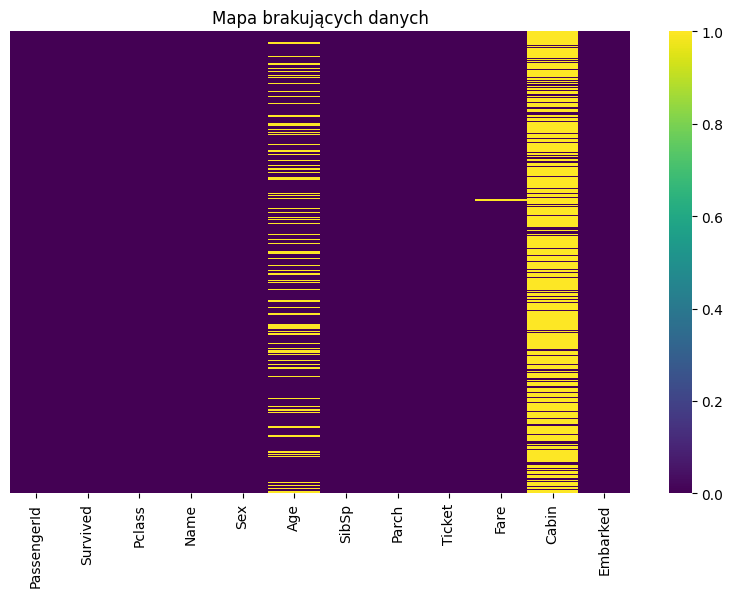

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title("Mapa brakujących danych przed")
plt.show()

In [88]:
import pandas as pd
import numpy as np
import random

def psuj_dataset(df: pd.DataFrame) -> pd.DataFrame:
    seed = 42
    np.random.seed(seed)
    random.seed(seed)

    df_zepsuty = df.copy()

    # 1. BRAKUJĄCE DANE - różne wzorce
    numeric_cols = df_zepsuty.select_dtypes(include=[np.number]).columns.tolist()
    df_zepsuty[numeric_cols] = df_zepsuty[numeric_cols].astype(float)
    categorical_cols = df_zepsuty.select_dtypes(include=['object', 'category']).columns.tolist()

    # nie imputujemy targetu
    numeric_cols = [col for col in numeric_cols if col != 'Survived']

    if len(numeric_cols) > 0:
        # MCAR - losowe braki w kolumnie numerycznej
        col_mcar = random.choice(numeric_cols)
        mask_mcar = np.random.random(len(df_zepsuty)) < 0.15
        df_zepsuty.loc[mask_mcar, col_mcar] = np.nan

        # MAR - braki zależne od innej zmiennej
        if len(numeric_cols) > 1:
            col_mar = random.choice([c for c in numeric_cols if c != col_mcar])
            threshold = df_zepsuty[col_mcar].quantile(0.7) if not df_zepsuty[col_mcar].isna().all() else 0
            mask_mar = (df_zepsuty[col_mcar] > threshold) & (np.random.random(len(df_zepsuty)) < 0.25)
            df_zepsuty.loc[mask_mar, col_mar] = np.nan

        # Kolumna z >60% braków do usunięcia
        if len(numeric_cols) > 2:
            col_duzo_brakow = random.choice([c for c in numeric_cols if c not in [col_mcar, col_mar] if 'col_mar' in locals()])
            mask_duzo = np.random.random(len(df_zepsuty)) < 0.65
            df_zepsuty.loc[mask_duzo, col_duzo_brakow] = np.nan

    if len(categorical_cols) > 0:
        # MNAR - braki w kategorycznej
        col_mnar = random.choice(categorical_cols)
        unique_vals = df_zepsuty[col_mnar].dropna().unique()
        if len(unique_vals) > 1:
            # Braki głównie w jednej kategorii
            target_val = random.choice(unique_vals)
            mask_mnar = (df_zepsuty[col_mnar] == target_val) & (np.random.random(len(df_zepsuty)) < 0.30)
            df_zepsuty.loc[mask_mnar, col_mnar] = np.nan

    # 2. DUPLIKATY
    n_duplicates = int(len(df_zepsuty) * 0.08)  # 8% duplikatów
    if n_duplicates > 0:
        duplicate_indices = np.random.choice(df_zepsuty.index, size=n_duplicates, replace=True)
        df_duplicates = df_zepsuty.loc[duplicate_indices].copy()
        df_zepsuty = pd.concat([df_zepsuty, df_duplicates], ignore_index=True)

    # 3. OUTLIERY
    if len(numeric_cols) > 0:
        for i, col in enumerate(numeric_cols[:min(3, len(numeric_cols))]):
            if df_zepsuty[col].notna().sum() > 0:
                # Różne typy outlierów
                n_outliers = int(len(df_zepsuty) * 0.03)
                outlier_indices = np.random.choice(df_zepsuty.index, size=n_outliers, replace=False)

                mean_val = df_zepsuty[col].mean()
                std_val = df_zepsuty[col].std()

                if i % 3 == 0:
                    # Ekstremalne wartości górne
                    df_zepsuty.loc[outlier_indices, col] = mean_val + (4 + np.random.random(n_outliers) * 3) * std_val
                elif i % 3 == 1:
                    # Ekstremalne wartości dolne
                    df_zepsuty.loc[outlier_indices, col] = mean_val - (4 + np.random.random(n_outliers) * 3) * std_val
                else:
                    # Mix górne i dolne
                    half = n_outliers // 2
                    df_zepsuty.loc[outlier_indices[:half], col] = mean_val + (4 + np.random.random(half) * 2) * std_val
                    df_zepsuty.loc[outlier_indices[half:], col] = mean_val - (4 + np.random.random(n_outliers-half) * 2) * std_val

    # 4. NIESPÓJNOŚCI W DANYCH
    if len(categorical_cols) > 0:
        col_niespojnosc = random.choice(categorical_cols)
        unique_vals = df_zepsuty[col_niespojnosc].dropna().unique()

        if len(unique_vals) > 0:
            # Różne warianty tej samej wartości (whitespace, case)
            n_niespojnosci = int(len(df_zepsuty) * 0.05)
            niespojnosc_indices = np.random.choice(df_zepsuty[df_zepsuty[col_niespojnosc].notna()].index,
                                                   size=min(n_niespojnosci, df_zepsuty[col_niespojnosc].notna().sum()),
                                                   replace=False)

            for idx in niespojnosc_indices:
                val = str(df_zepsuty.loc[idx, col_niespojnosc])
                # Losowy wybór problemu
                problem = random.choice(['lowercase', 'uppercase', 'whitespace', 'typo'])

                if problem == 'lowercase':
                    df_zepsuty.loc[idx, col_niespojnosc] = val.lower()
                elif problem == 'uppercase':
                    df_zepsuty.loc[idx, col_niespojnosc] = val.upper()
                elif problem == 'whitespace':
                    df_zepsuty.loc[idx, col_niespojnosc] = f"  {val}  "
                elif problem == 'typo' and len(val) > 2:
                    # Zamień losową literę
                    pos = random.randint(0, len(val)-1)
                    val_list = list(val)
                    val_list[pos] = random.choice('abcdefghijklmnopqrstuvwxyz')
                    df_zepsuty.loc[idx, col_niespojnosc] = ''.join(val_list)

    # 5. WARTOŚCI POZA SENSOWNYM ZAKRESEM
    if len(numeric_cols) > 0:
        col_nonsense = random.choice([c for c in numeric_cols if c != col_mcar])
        nonsense_indices = np.random.choice(df_zepsuty.index, size=int(len(df_zepsuty) * 0.02), replace=False)

        # Np. ujemne wartości gdzie powinny być dodatnie
        if df_zepsuty[col_nonsense].min() >= 0:
            df_zepsuty.loc[nonsense_indices, col_nonsense] = -abs(df_zepsuty.loc[nonsense_indices, col_nonsense])
        else:
            # Lub bardzo nietypowe wartości
            df_zepsuty.loc[nonsense_indices, col_nonsense] = df_zepsuty[col_nonsense].max() * 100

    # 6. PROBLEMY Z MULTIKOLINEARNOŚCIĄ - stwórz skorelowane kolumny
    if len(numeric_cols) >= 2:
        base_col = random.choice(numeric_cols)
        new_col_name = f"{base_col}_correlated"

        # Stwórz kolumnę silnie skorelowaną (r > 0.9)
        noise = np.random.normal(0, df_zepsuty[base_col].std() * 0.1, len(df_zepsuty))
        df_zepsuty[new_col_name] = df_zepsuty[base_col] * 1.5 + noise + 10

    # Wymieszaj kolejność wierszy
    df_zepsuty = df_zepsuty.sample(frac=1, random_state=seed).reset_index(drop=True)

    return df_zepsuty

In [89]:
df_zepsuty = psuj_dataset(df)

df_zepsuty.isnull().sum()

C:\Users\USER098\AppData\Local\Temp\ipykernel_16456\4155442186.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_zepsuty.select_dtypes(include=['object', 'category']).columns.tolist()


PassengerId         23
Survived             0
Pclass             272
Name                 0
Sex                  0
Age                 89
SibSp                0
Parch                0
Ticket               0
Fare                78
Cabin              353
Embarked             0
Fare_correlated     78
dtype: int64

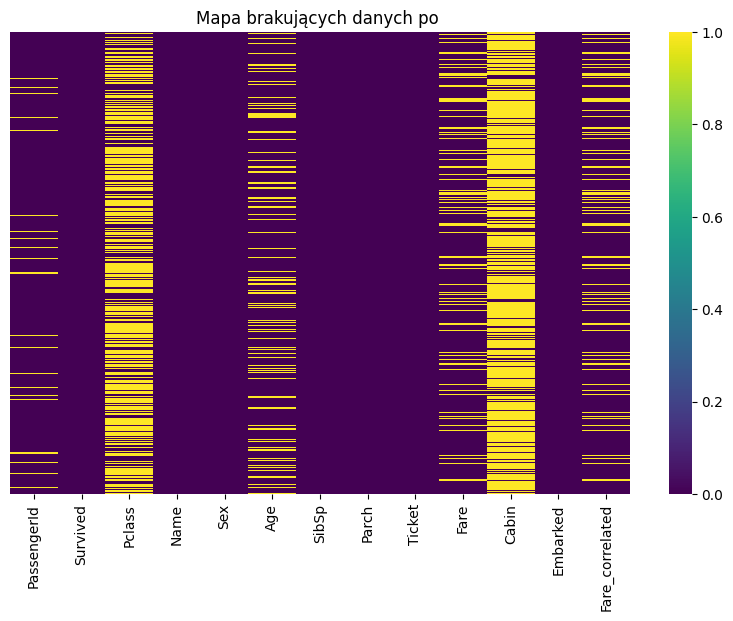

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df_zepsuty.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title("Mapa brakujących danych po ")
plt.show()

In [91]:
duplicate_count = df.duplicated().sum()
total_rows = len(df)

duplicate_percent = (duplicate_count / total_rows) * 100
original_percent = 100 - duplicate_percent


missing_df = pd.DataFrame({
    'Liczba_brakow': df_zepsuty.isnull().sum(),
    'Procent_brakow': (df_zepsuty.isnull().mean() * 100).round(2),
    'Liczba_duplikatów': df.duplicated().sum(),
    'Procent_duplikatów': duplicate_percent    
})

missing_df

,Liczba_brakow,Procent_brakow,Liczba_duplikatów,Procent_duplikatów
PassengerId,23,5.10,0,0.0
Survived,0,0.00,0,0.0
Pclass,272,60.31,0,0.0
Name,0,0.00,0,0.0
Sex,0,0.00,0,0.0
Age,89,19.73,0,0.0
SibSp,0,0.00,0,0.0
Parch,0,0.00,0,0.0
Ticket,0,0.00,0,0.0
Fare,78,17.29,0,0.0


# 2.1 handling missing values

In [92]:
df_zepsuty = psuj_dataset(df)
df_zepsuty.isnull().sum()

C:\Users\USER098\AppData\Local\Temp\ipykernel_16456\4155442186.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_zepsuty.select_dtypes(include=['object', 'category']).columns.tolist()


PassengerId         23
Survived             0
Pclass             272
Name                 0
Sex                  0
Age                 89
SibSp                0
Parch                0
Ticket               0
Fare                78
Cabin              353
Embarked             0
Fare_correlated     78
dtype: int64

In [122]:
def czysc(df: pd.DataFrame) -> pd.DataFrame:
    
    czysty_df = df.copy()

    if 'Cabin' in czysty_df.columns:
        czysty_df.drop(columns=['Cabin'], inplace=True)
    
    numeric_cols = czysty_df.select_dtypes(include=[np.number]).columns.tolist()
    # imputacja numerycznych medianą
    for col in numeric_cols:
        czysty_df[col] = czysty_df[col].fillna(czysty_df[col].median())

    categorical_cols = czysty_df.select_dtypes(include=['object', 'category']).columns.tolist()
    # imputacja kategorycznych modą
    for col in categorical_cols:
        czysty_df[col] = czysty_df[col].fillna(czysty_df[col].mode()[0])
    
    
    # usuwanie kolumn >60% braków usuniecie Cabin
    missing_percent = czysty_df.isnull().mean() * 100
    cols_to_drop = missing_percent[missing_percent > 60].index
    czysty_df.drop(columns=cols_to_drop, inplace=True)

    # usuwanie duplikatów
    czysty_df.drop_duplicates(inplace=True)

    return czysty_df

In [133]:
czysty_df=czysc(df_zepsuty)
print(czysty_df.isnull().sum())
czysty_df

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Embarked           0
Fare_correlated    0
dtype: int64


C:\Users\USER098\AppData\Local\Temp\ipykernel_16456\3193405061.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = czysty_df.select_dtypes(include=['object', 'category']).columns.tolist()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Fare_correlated
0,1190.0,0.0,1.0,"Loring, Mr. Joseph Holland",male,30.0,0.0,0.0,113801,45.5000,S,83.228010
1,931.0,0.0,2.0,"Hee, Mr. Ling",male,27.0,0.0,0.0,1601,56.4958,S,104.304171
2,1227.0,0.0,1.0,"Maguire, Mr. John Edward",male,30.0,0.0,0.0,110469,14.5000,S,33.070958
3,1290.0,0.0,3.0,"Larsson-Rondberg, Mr. Edvard A",male,22.0,0.0,0.0,347065,7.7750,S,26.139860
4,1045.0,1.0,3.0,"Klasen, Mrs. (Hulda Kristina Eugenia Lofqvist)",female,36.0,0.0,2.0,350405,12.1833,S,26.644707
...,...,...,...,...,...,...,...,...,...,...,...,...
446,998.0,0.0,3.0,"Buckley, Mr. Daniel",male,21.0,0.0,0.0,330920,7.8208,Q,22.868271
447,1162.0,0.0,2.0,"McCaffry, Mr. Thomas Francis",male,46.0,0.0,0.0,13050,75.2417,C,120.332437
448,1240.0,0.0,2.0,"Giles, Mr. Ralph",male,24.0,0.0,0.0,248726,13.5000,S,38.403446
449,916.0,1.0,1.0,"Ryerson, Mrs. Arthur Larned (Emily Maria Borie)",female,48.0,1.0,3.0,PC 17608,262.3750,C,397.801507


# 2.2 Outlier detection and handling


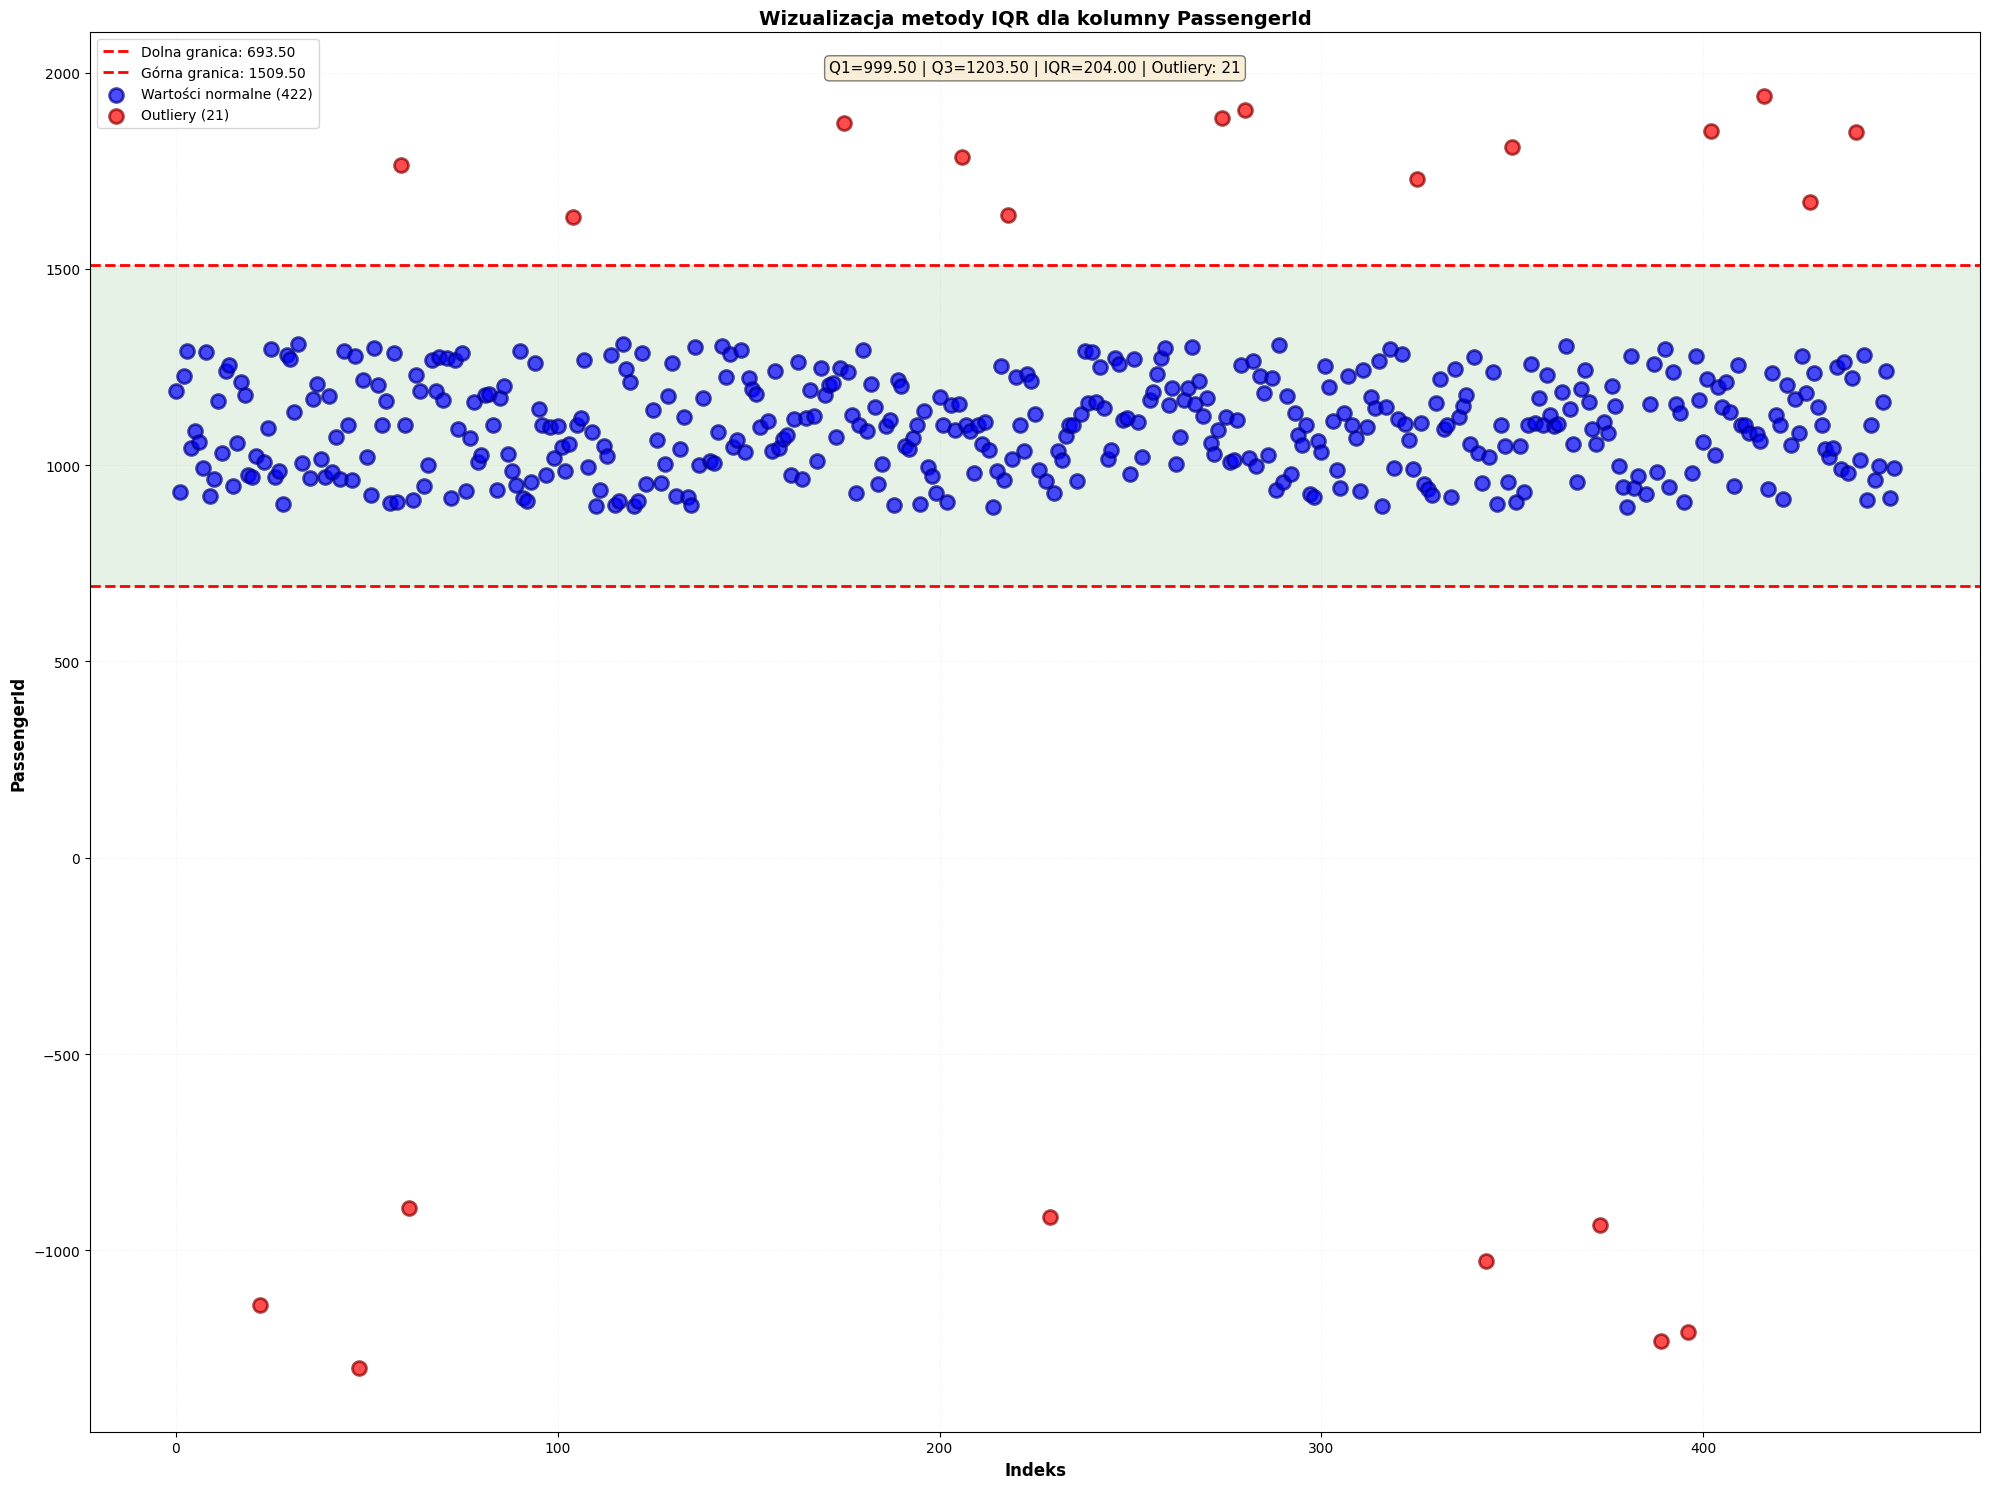

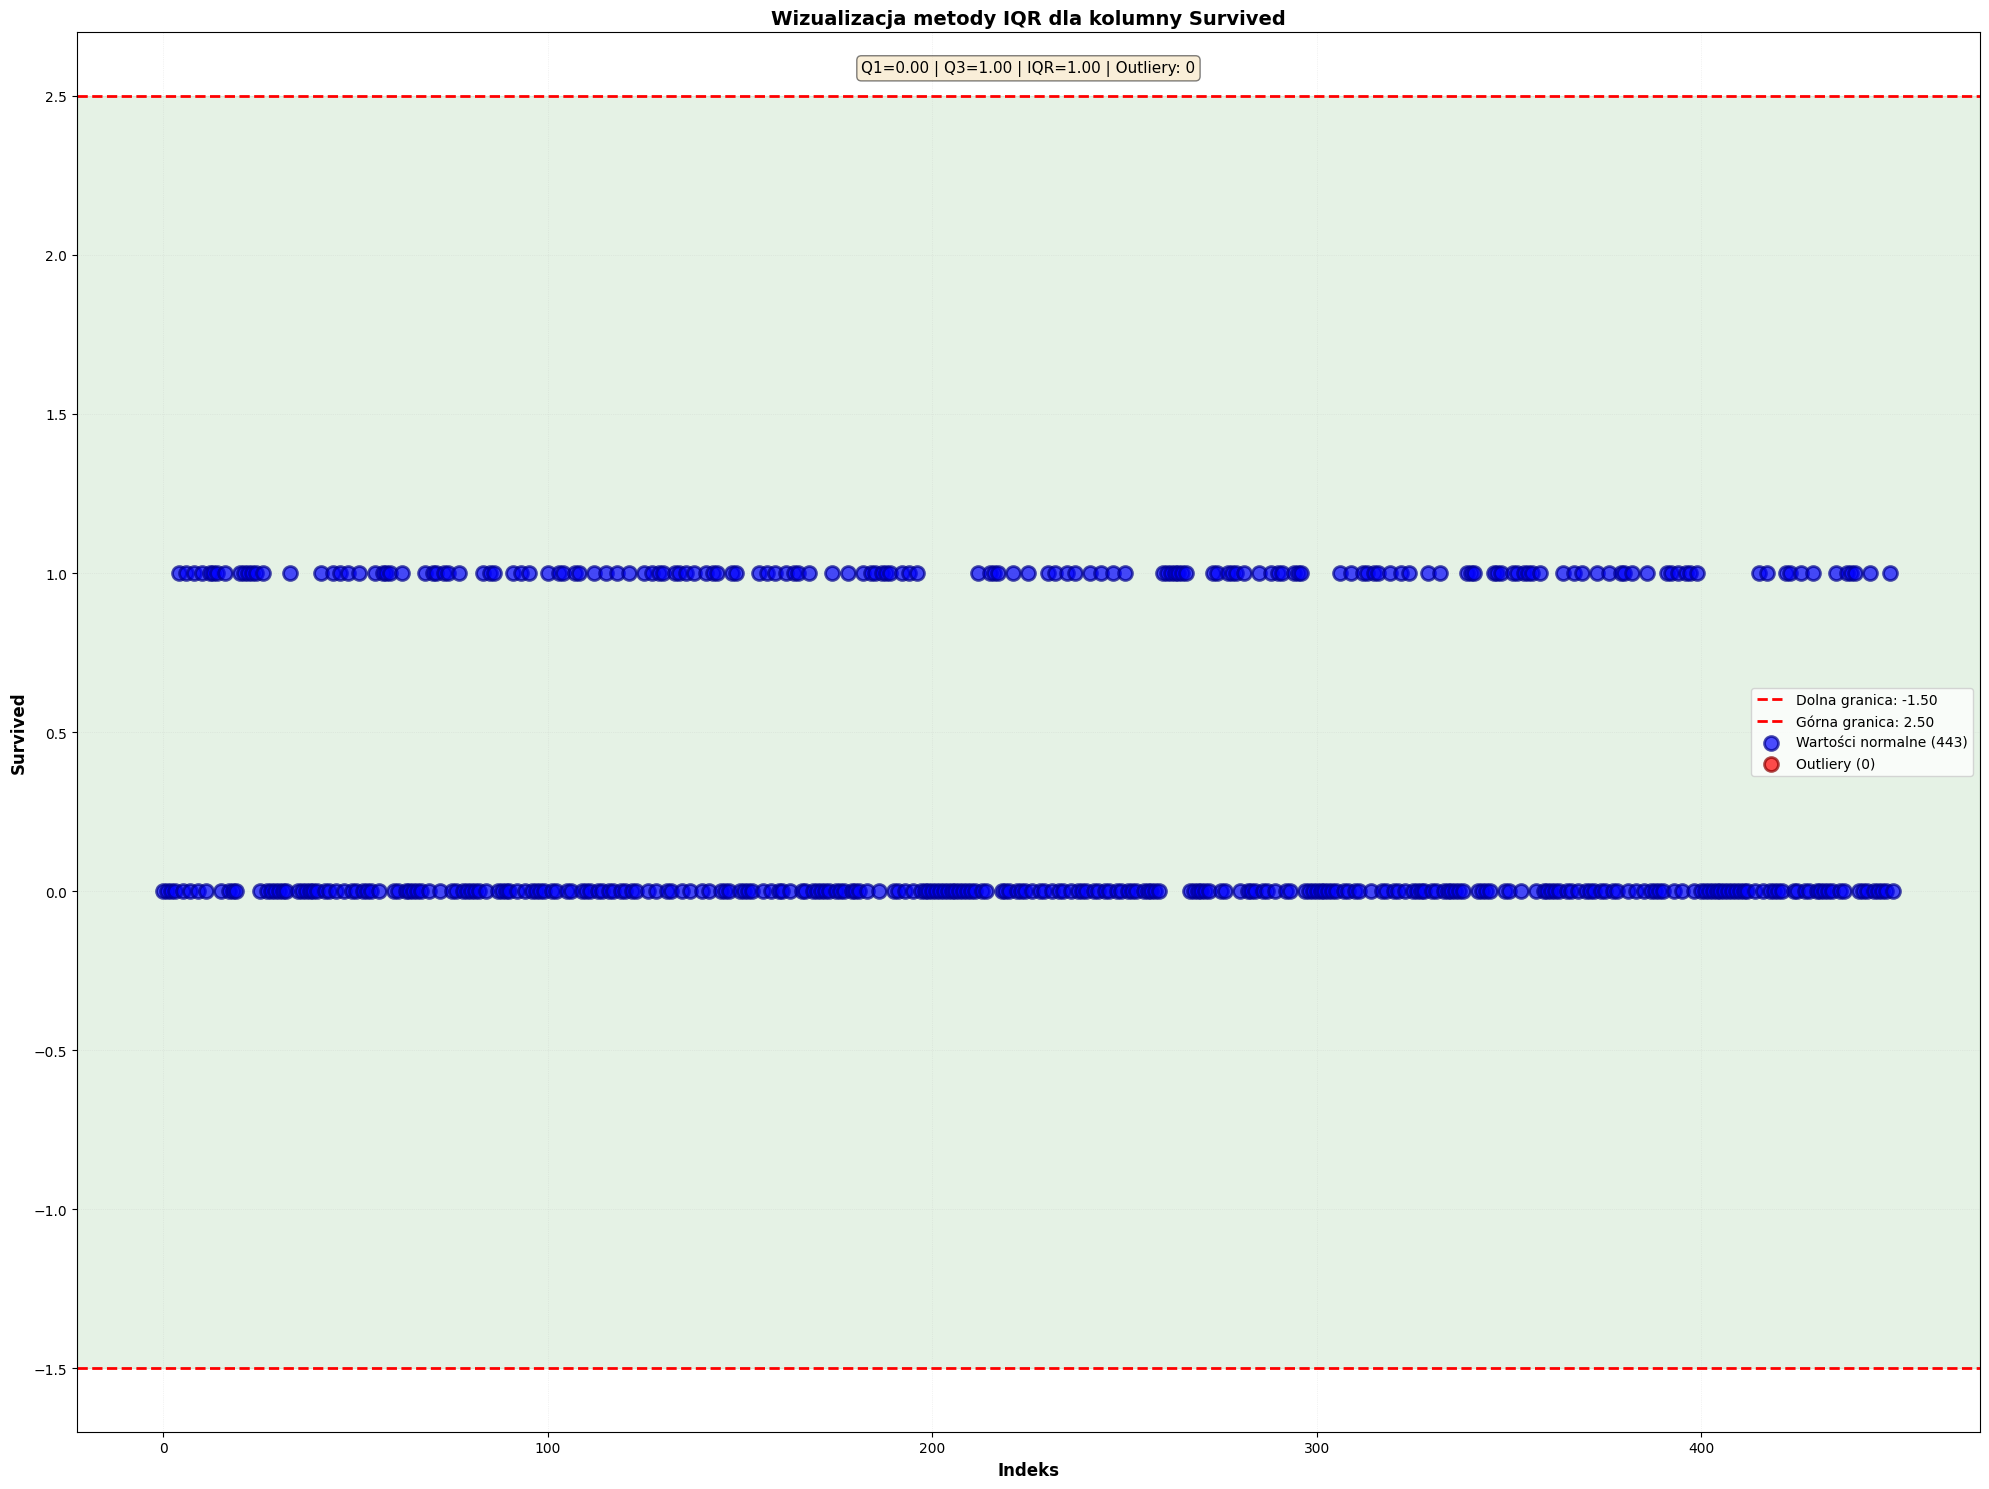

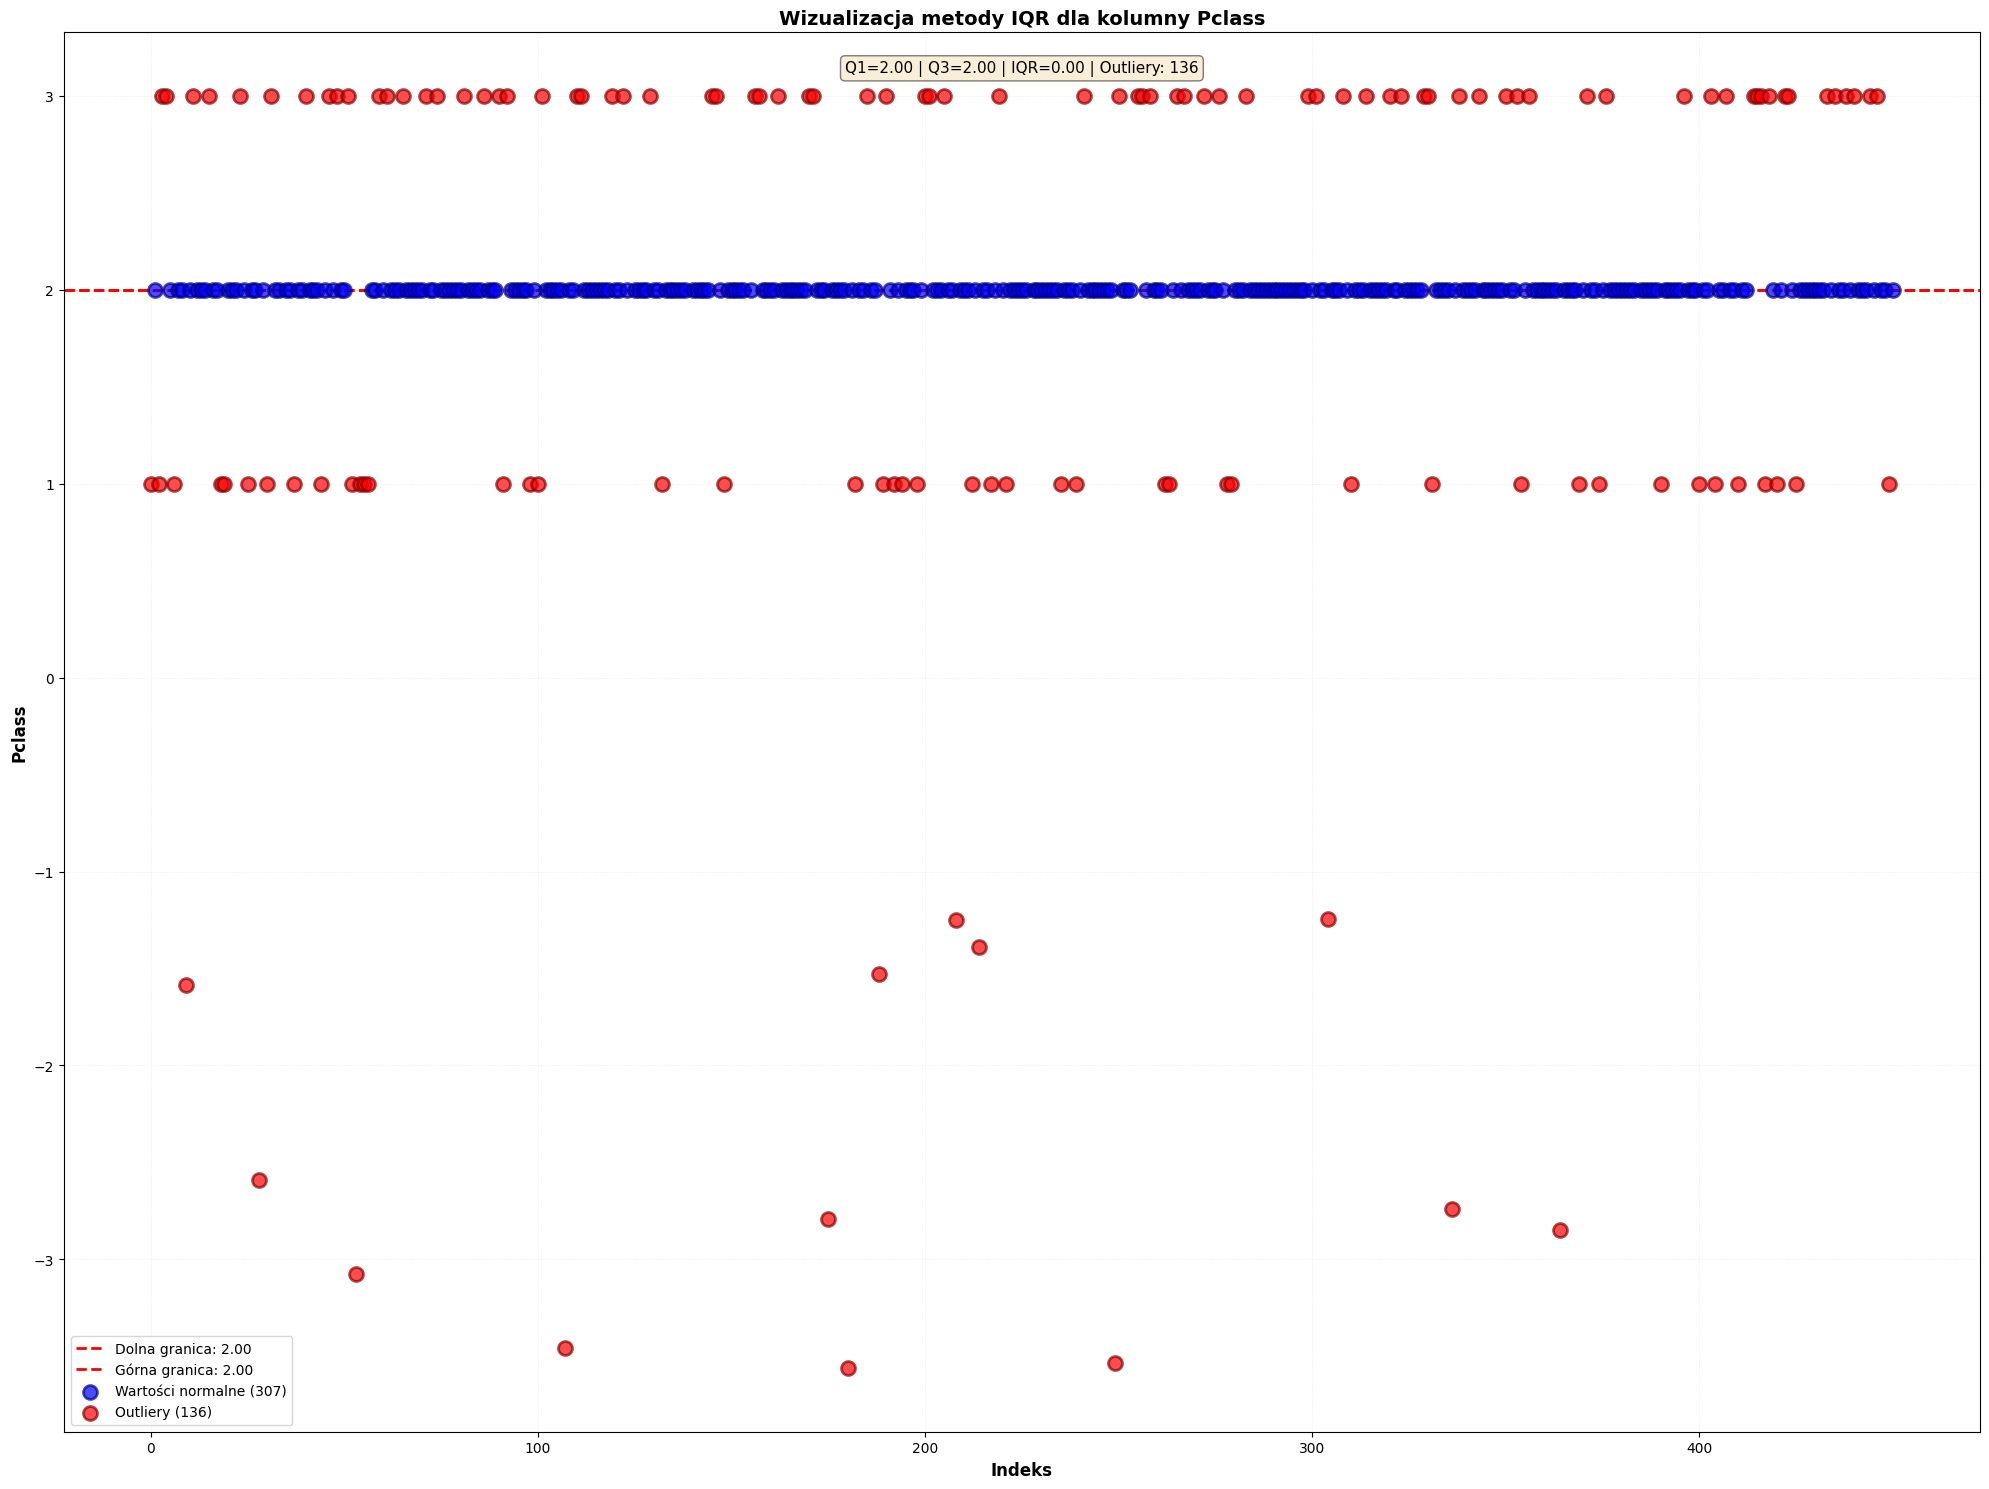

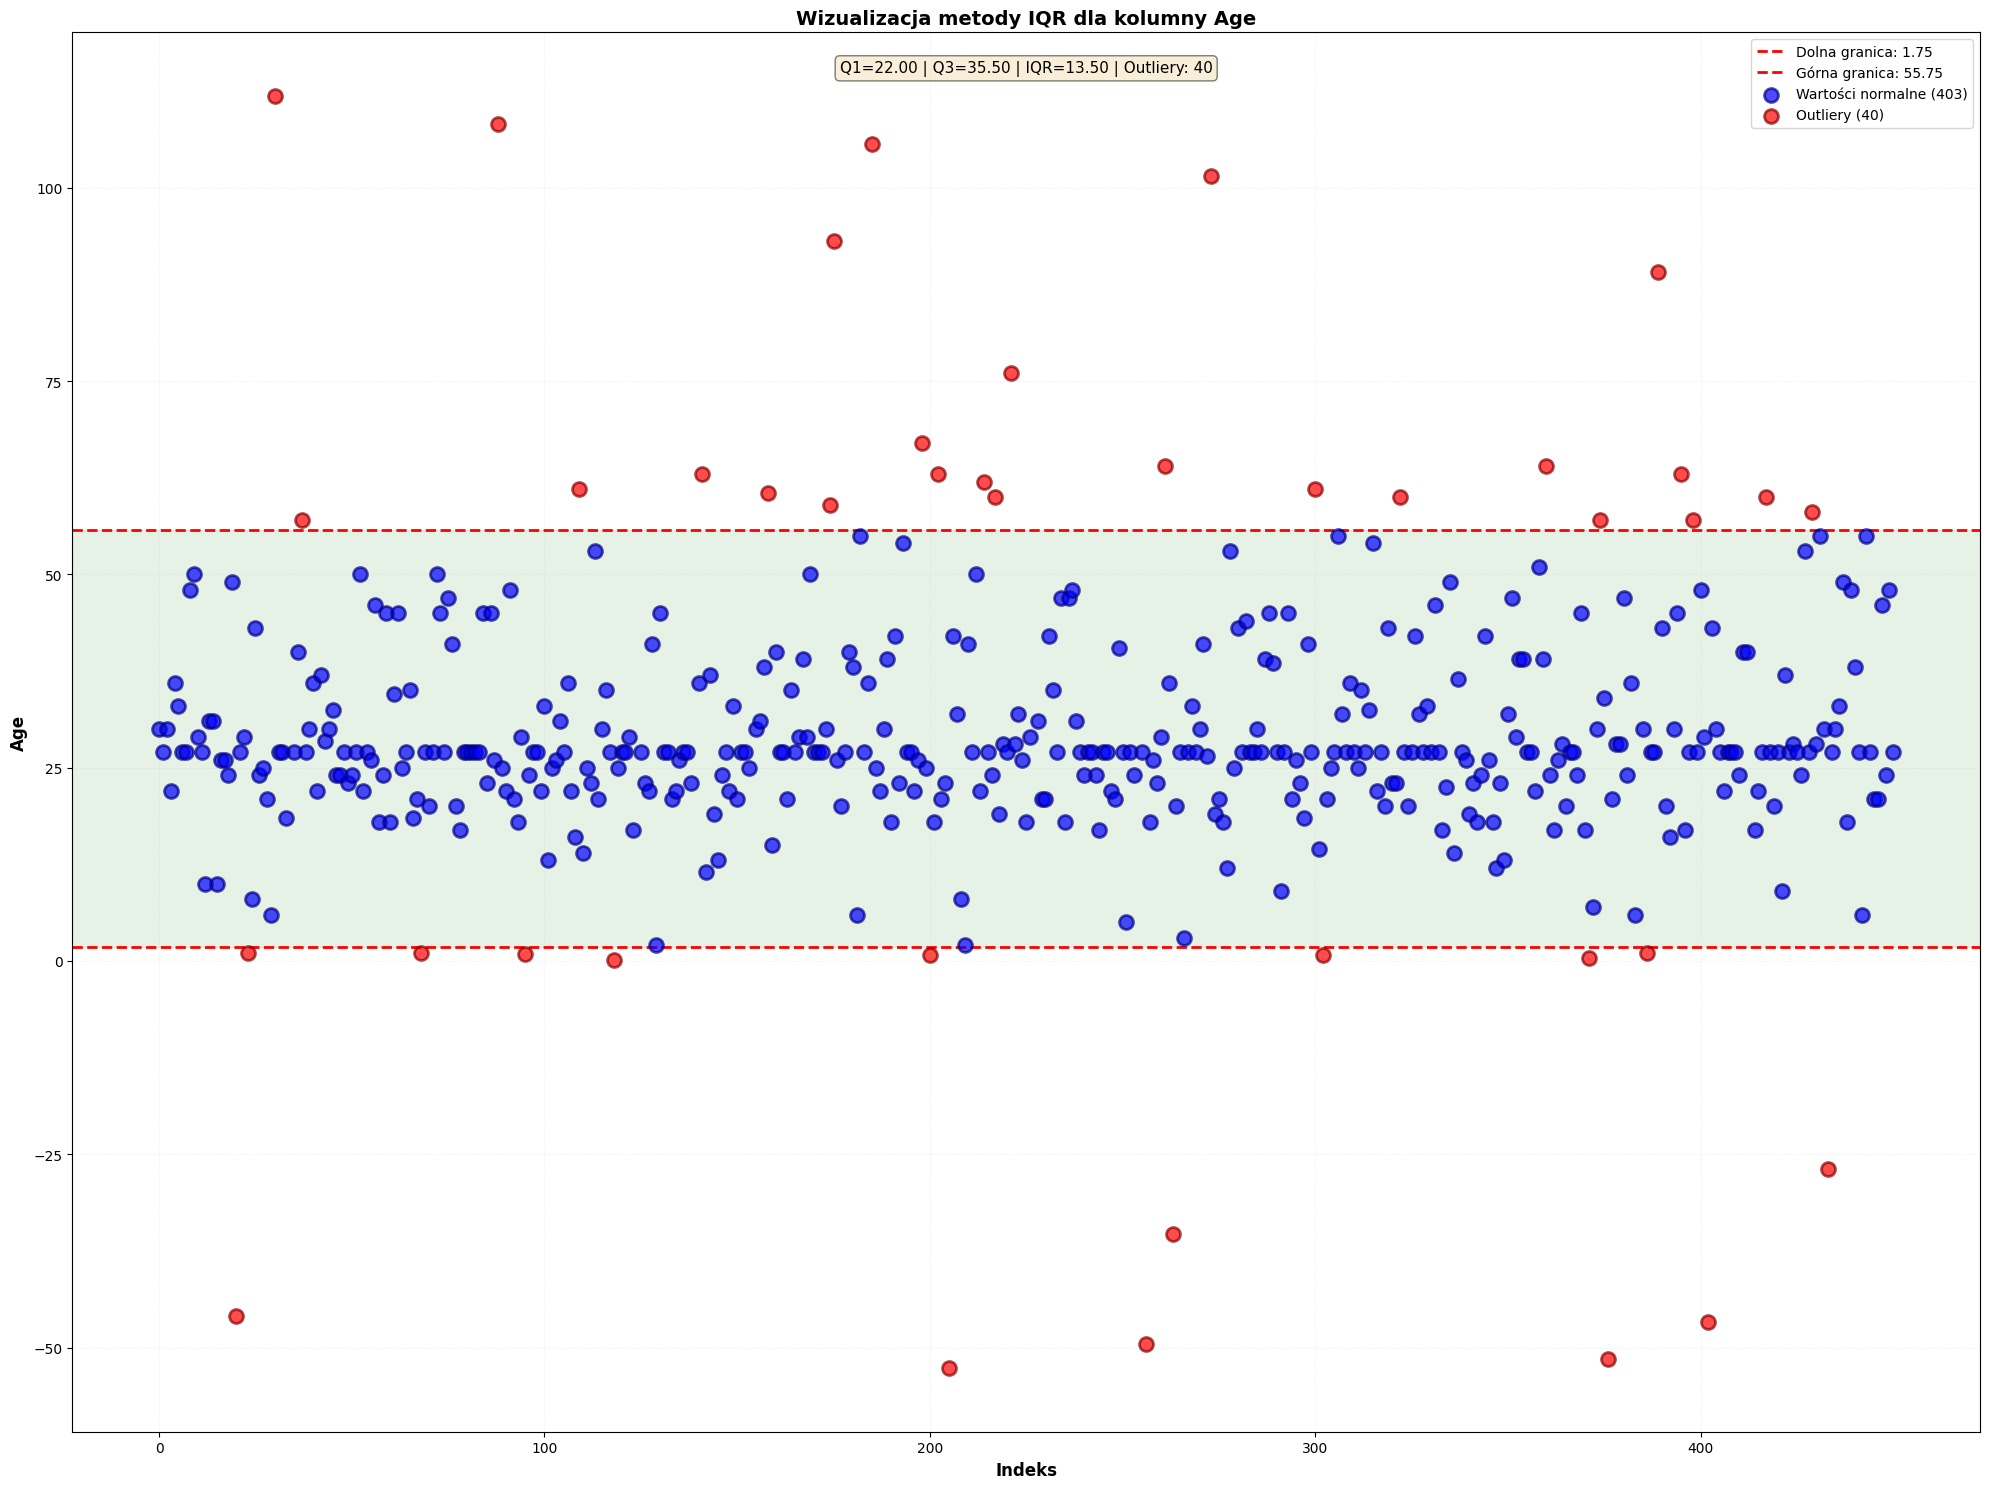

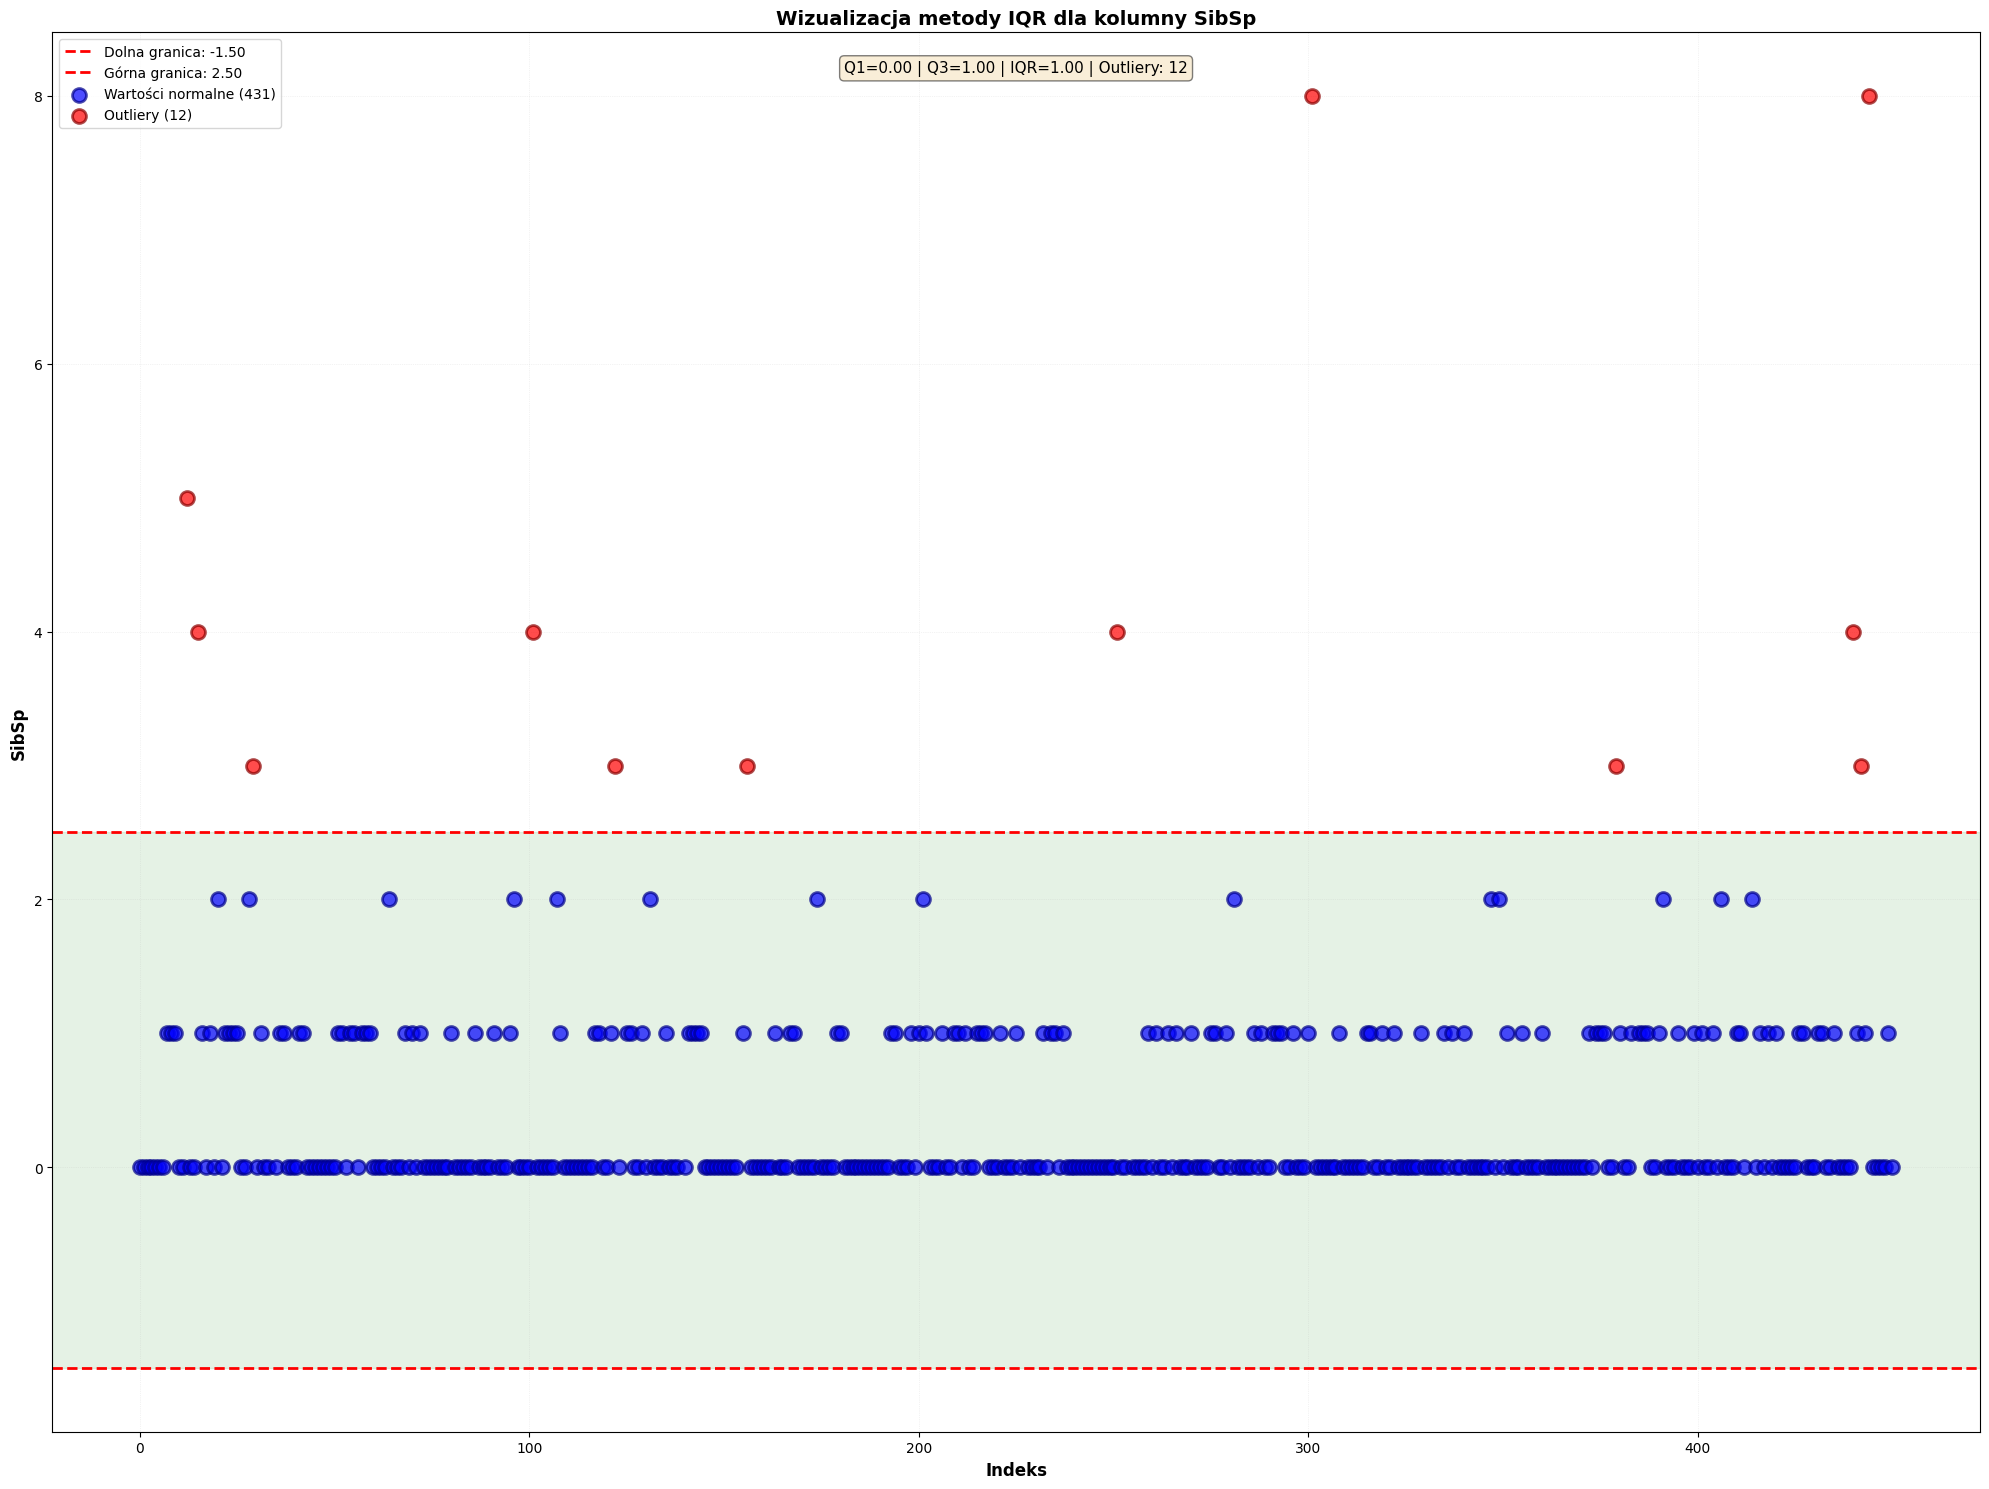

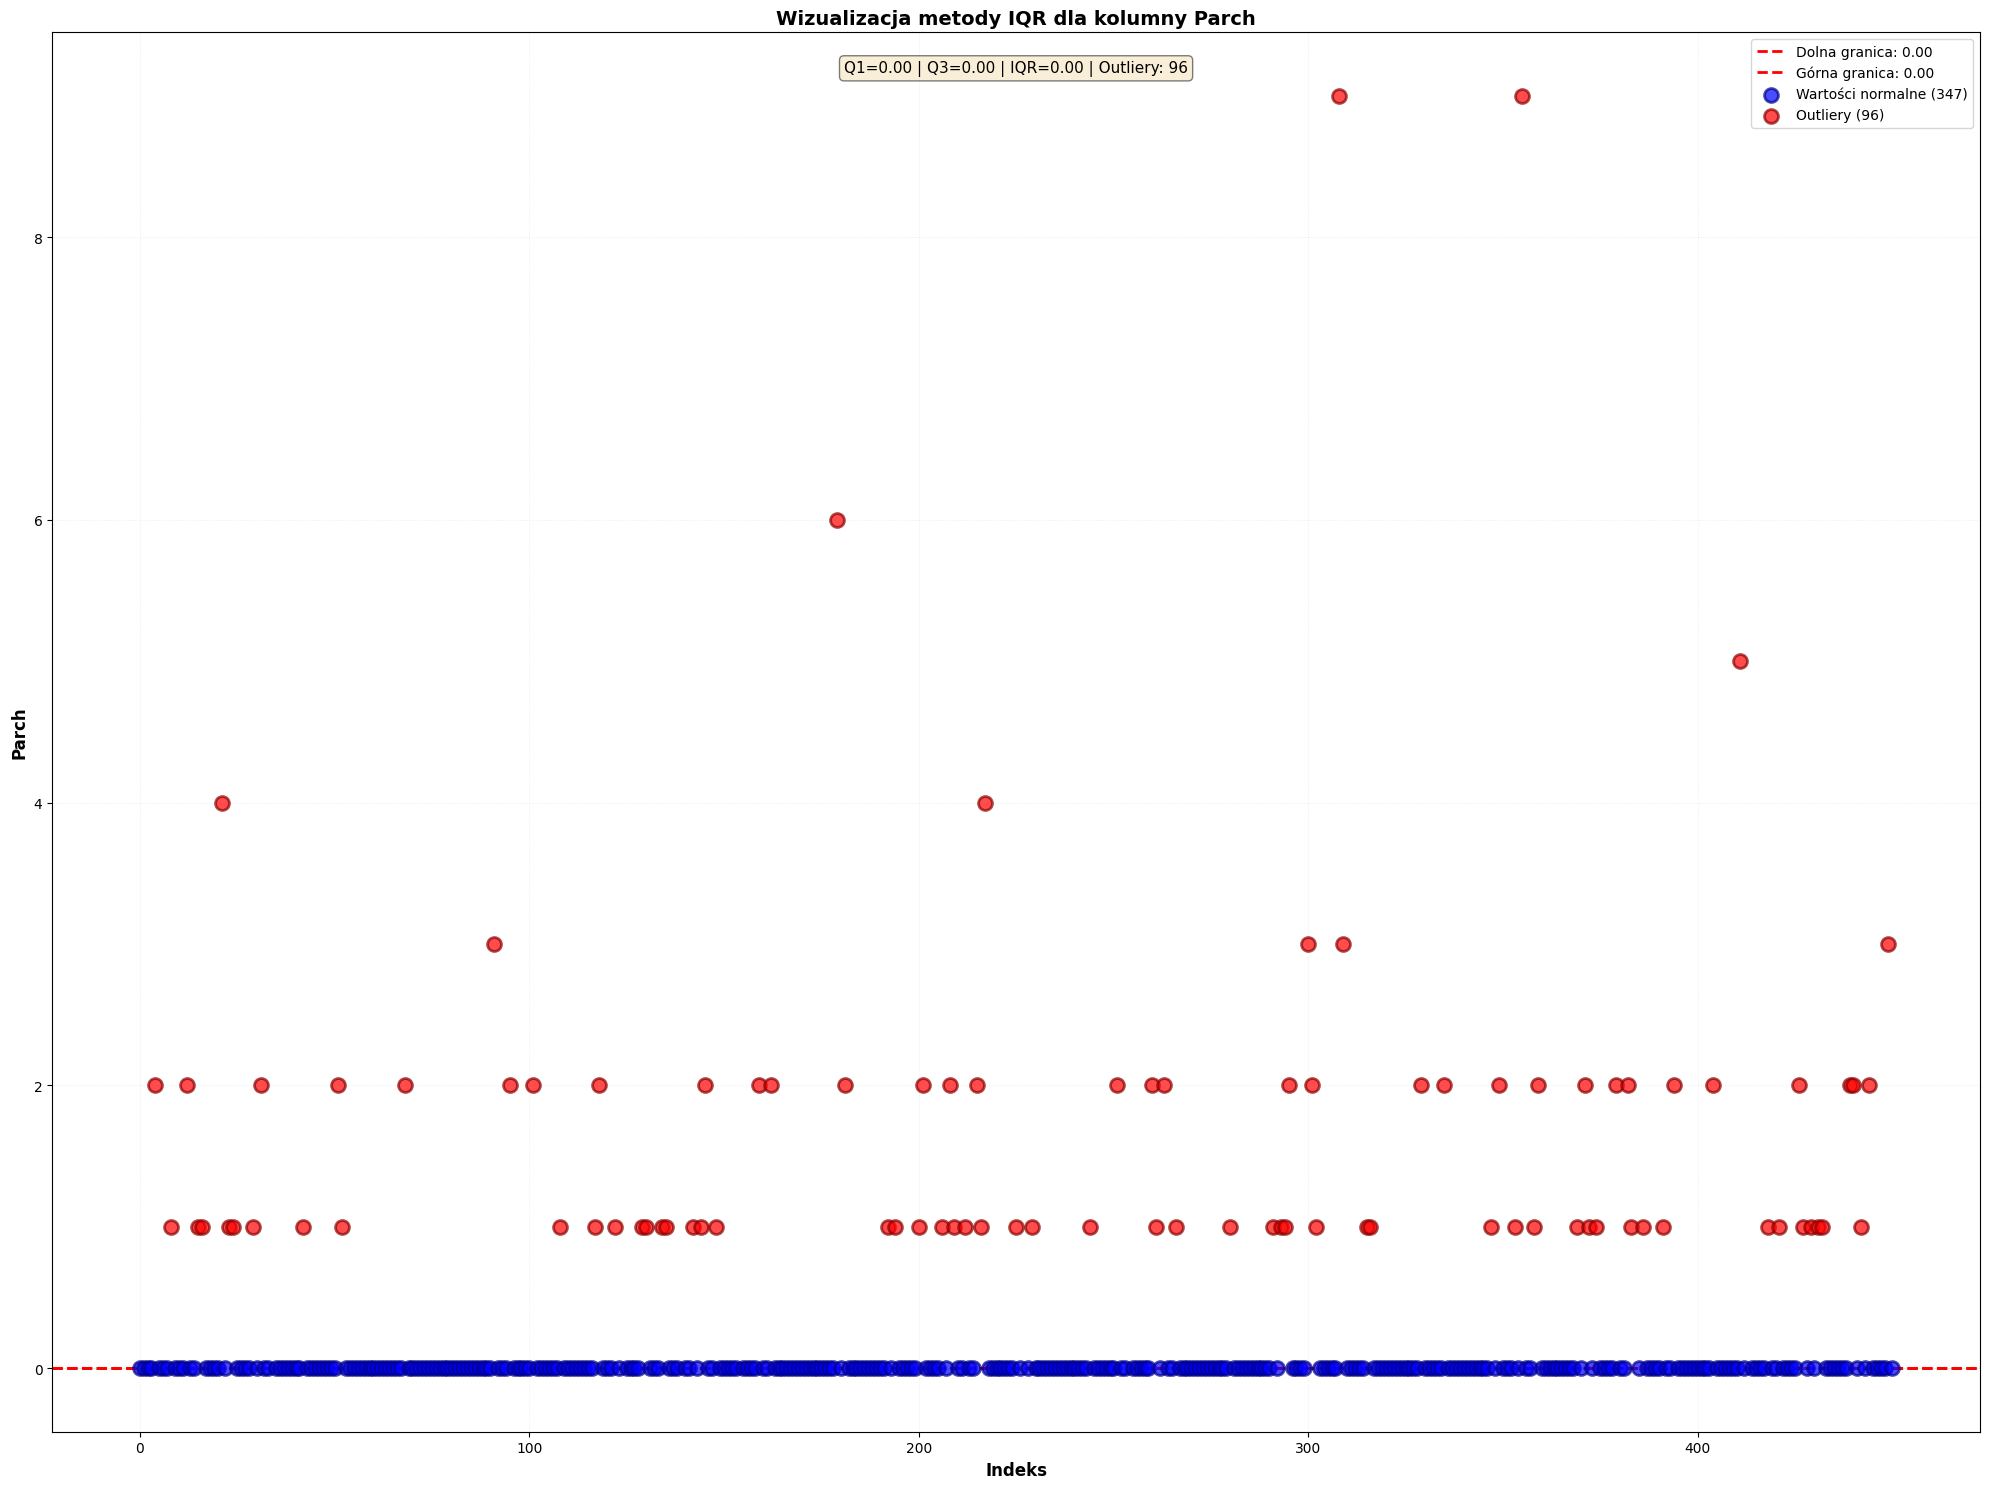

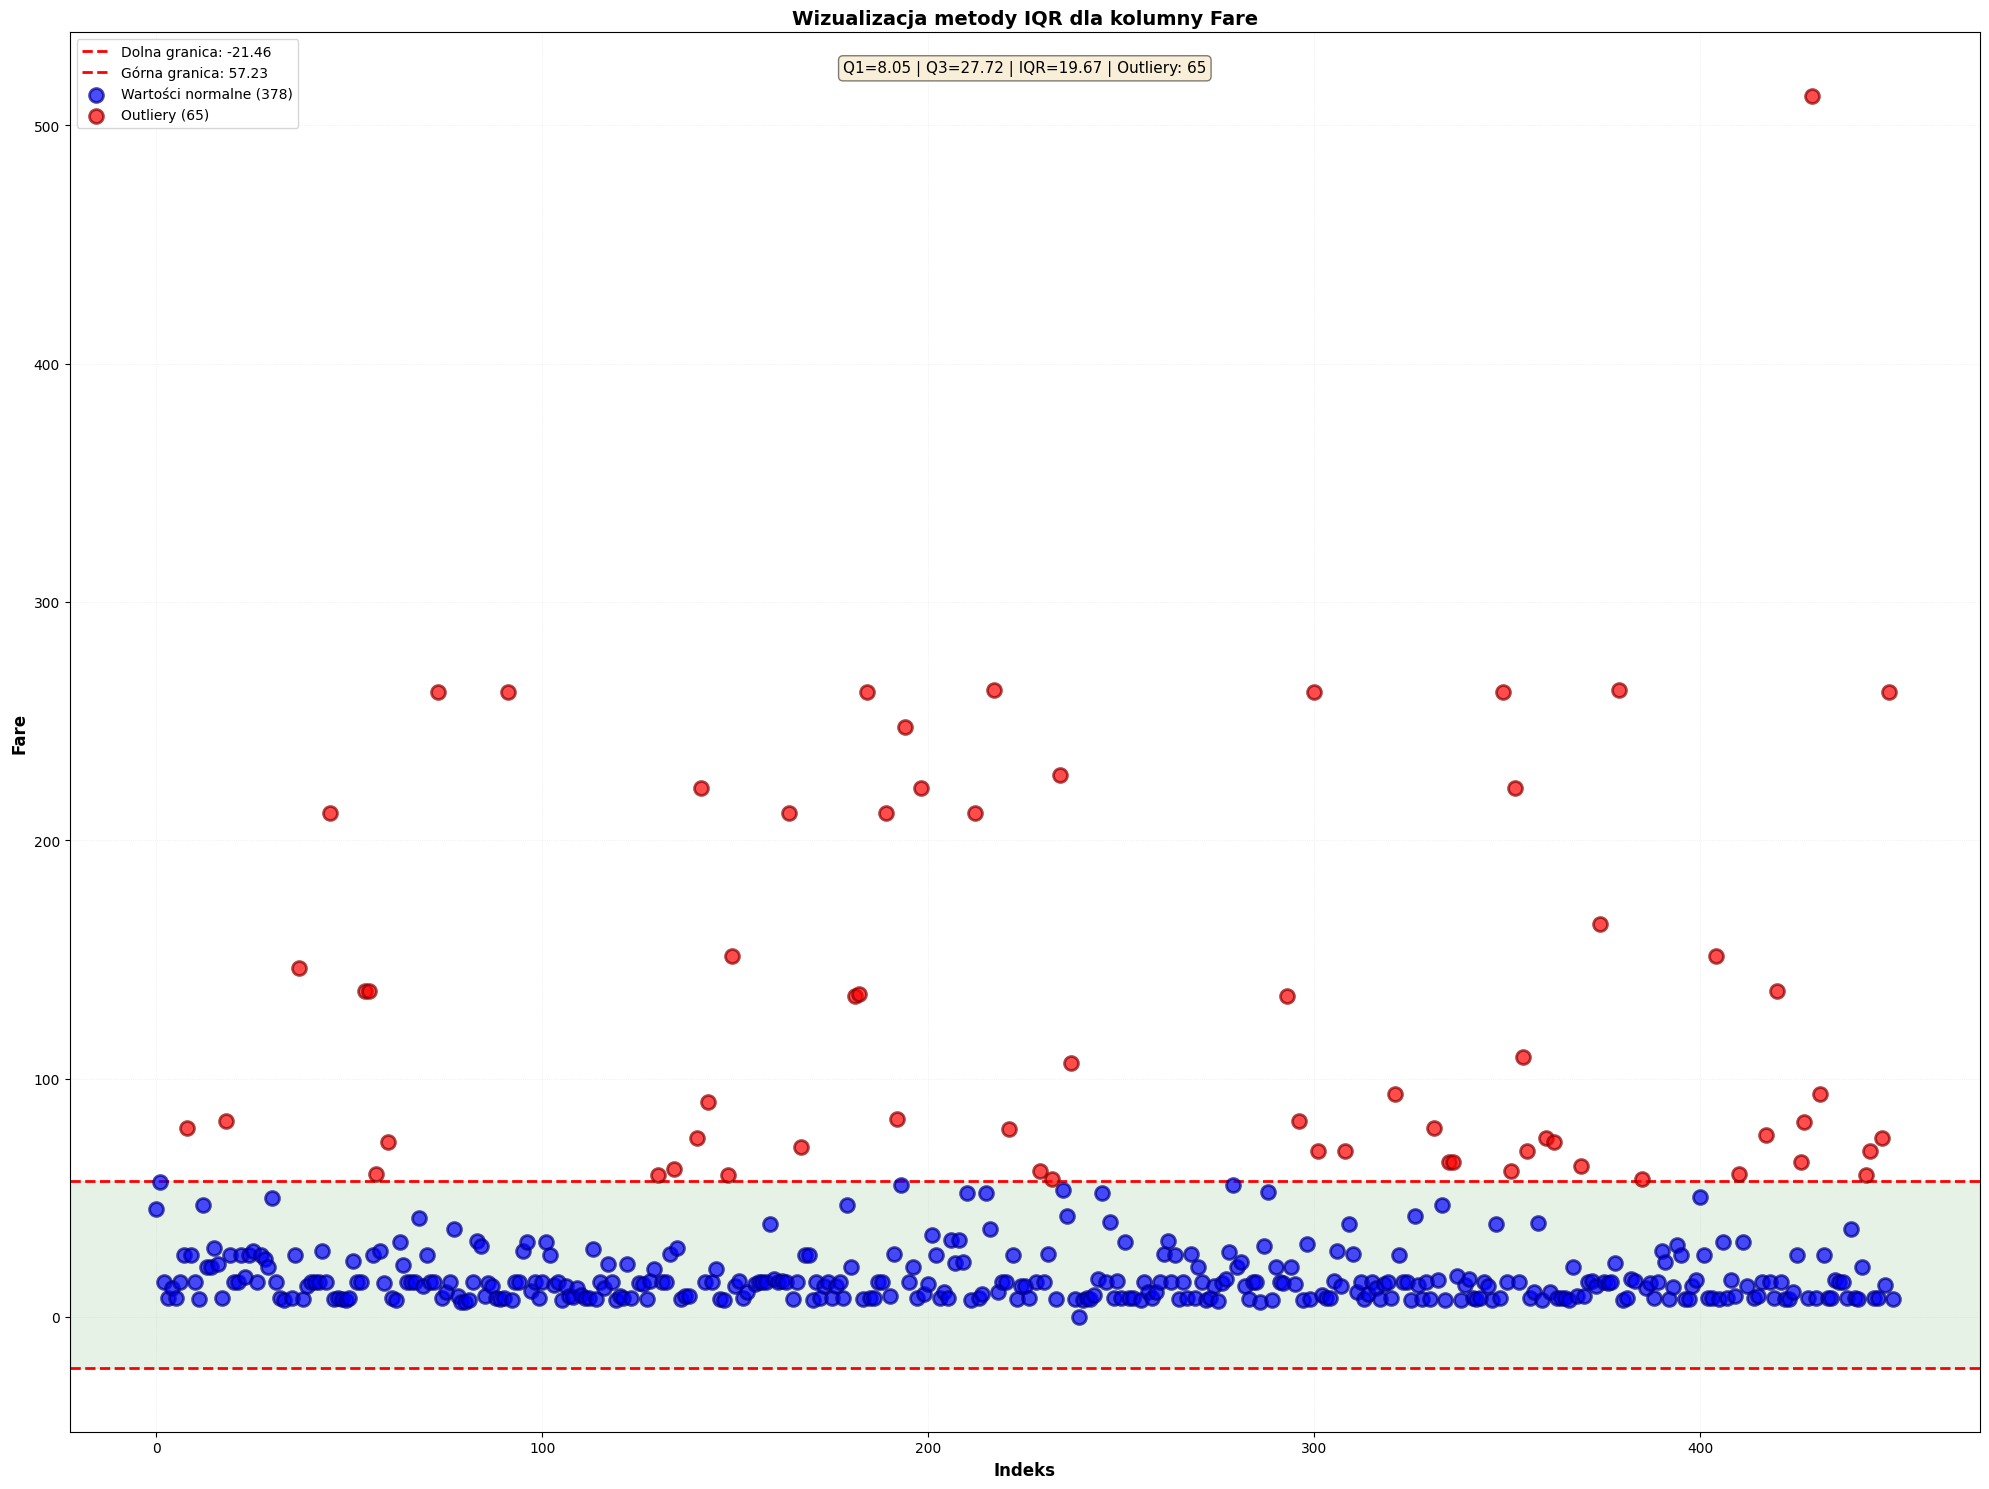

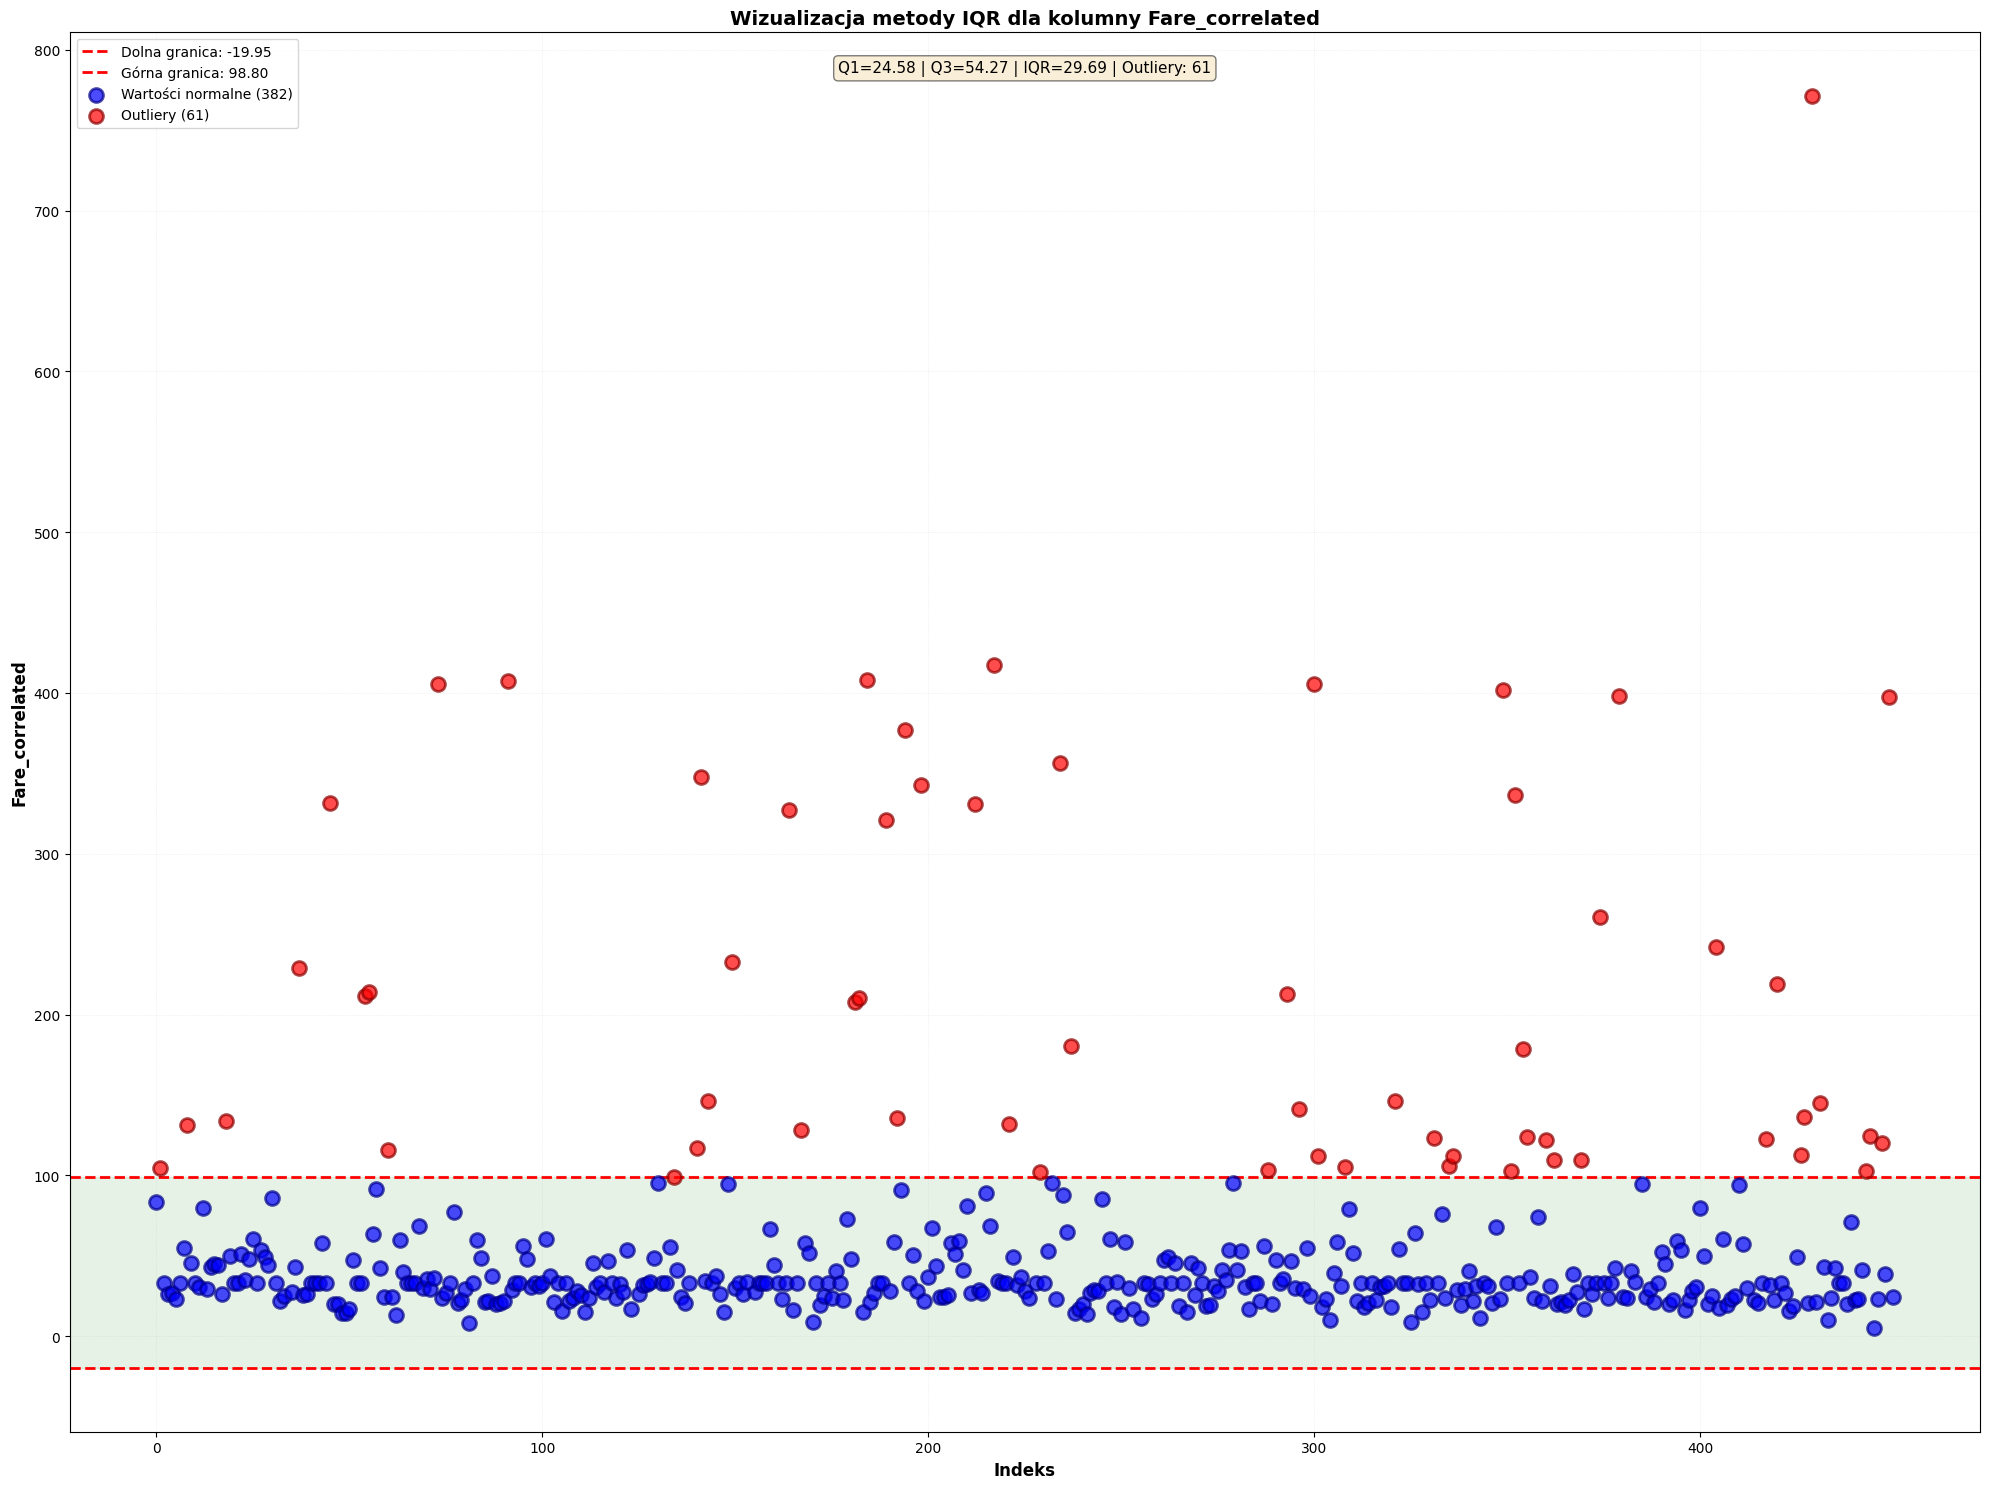

In [54]:
for col in czysty_df.select_dtypes(include=[np.number]).columns:
    
  # Obliczanie Qwantyli 1 i 3
  Q1 =  czysty_df[col].quantile(0.25)
  Q3 =  czysty_df[col].quantile(0.75)
  Q1, Q3

  # Obliczanie IQR
  IQR = Q3 - Q1
  IQR

  #Generowanie Wykresu z danych dla konkretnej kolumny
  top_line = (Q1- 1.5 * IQR)
  bottom_line = (Q3 + 1.5 * IQR)
  outliners = czysty_df[(czysty_df[col] < top_line) | (czysty_df[col] > bottom_line)]

  normal = czysty_df[(czysty_df[col] >= top_line) & (czysty_df[col] <= bottom_line)]

  plt.figure(figsize=(20, 15))

  plt.axhspan(top_line, bottom_line, alpha=0.1, color='green')

  plt.axhline(y=top_line, color='red', linestyle='--', linewidth=2,
            label=f'Dolna granica: {top_line:.2f}')
  plt.axhline(y=bottom_line, color='red', linestyle='--', linewidth=2,
            label=f'Górna granica: {bottom_line:.2f}')

  plt.scatter(normal.index, normal[col], c='blue', s=100,
            alpha=0.7, edgecolors='darkblue', linewidth=2,
            label=f'Wartości normalne ({len(normal)})', zorder=5)

  plt.scatter(outliners.index, outliners[col], c='red', s=100,
            alpha=0.7, edgecolors='darkred', linewidth=2,
            label=f'Outliery ({len(outliners)})', zorder=5)

  plt.xlabel('Indeks', fontsize=12, fontweight='bold')
  plt.ylabel(col, fontsize=12, fontweight='bold')
  plt.title('Wizualizacja metody IQR dla kolumny ' + col, fontsize=14, fontweight='bold')
  plt.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
  plt.legend(loc='best', fontsize=10)

  info = f'Q1={Q1:.2f} | Q3={Q3:.2f} | IQR={IQR:.2f} | Outliery: {len(outliners)}'
  plt.text(0.5, 0.98, info, transform=plt.gca().transAxes,
          fontsize=11, va='top', ha='center',
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

  plt.tight_layout()
  plt.show()

In [103]:
from sklearn.ensemble import IsolationForest

# Dopasowanie modelu Isolation Forest
isolation_forest = IsolationForest(contamination=0.05)
czysty_df["outliers"] = isolation_forest.fit_predict(czysty_df[["Age", "Fare"]])

# Wyswietlenie wartosci odstajacych
czysty_df[czysty_df["outliers"] ==-1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Fare_correlated,outliers
8,1289.0,1.0,2.000000,"Frolicher-Stehli, Mrs. Maxmillian (Margaretha ...",female,48.00,1.0,1.0,13567,79.2000,C,131.190458,-1
12,1032.0,1.0,2.000000,"Goodwin, Miss. Jessie Allis",female,10.00,5.0,2.0,CA 2144,46.9000,S,79.696561,-1
68,1188.0,1.0,2.000000,"Laroche, Miss. Louise",female,1.00,1.0,2.0,SC/Paris 2123,41.5792,C,68.240758,-1
95,1142.0,1.0,2.000000,"West, Miss. Barbara J",female,0.92,1.0,2.0,C.A. 34651,27.7500,S,55.858133,-1
109,1085.0,0.0,2.000000,"Lingane, Mr. John",MALE,61.00,0.0,0.0,235509,12.3500,Q,28.048170,-1
143,1303.0,1.0,2.000000,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.00,1.0,0.0,19928,90.0000,Q,145.987699,-1
158,1044.0,0.0,2.000000,"Storey, Mr. Thomas",male,60.50,0.0,0.0,3701,14.5000,S,33.070958,-1
193,1069.0,0.0,2.000000,"Stengel, Mr. Charles Emil Henry",male,54.00,1.0,0.0,11778,55.4417,C,90.860799,-1
202,905.0,0.0,2.000000,"Howard, Mr. Benjamin",male,63.00,1.0,0.0,24065,26.0000,S,43.484020,-1
214,894.0,0.0,-1.391418,"Myles, Mr. Thomas Francis",male,62.00,0.0,0.0,240276,9.6875,Q,26.751965,-1


In [104]:
czysty_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Fare_correlated,outliers
count,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000
mean,1082.539853,0.345865,1.982910,28.275689,0.431078,0.350877,21.176817,42.224509,0.899749
std,329.632586,0.476247,0.927018,11.467061,0.904837,0.949580,19.191064,29.194258,0.436955
min,-1300.000000,0.000000,-3.561306,0.170000,0.000000,0.000000,0.000000,4.694493,-1.000000
25%,1000.500000,0.000000,2.000000,22.000000,0.000000,0.000000,8.050000,24.336327,1.000000
50%,1101.500000,0.000000,2.000000,27.000000,0.000000,0.000000,14.500000,33.070958,1.000000
75%,1210.500000,1.000000,2.000000,32.000000,1.000000,0.000000,26.000000,48.170864,1.000000
max,1940.567387,1.000000,3.000000,64.000000,8.000000,9.000000,108.900000,180.484391,1.000000


In [108]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

df_no_outliers = df[(df['Fare'] >= Q1 - 1.5*IQR) & (df['Fare'] <= Q3 + 1.5*IQR)]
df_no_outliers.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,362.000000,362.000000,362.000000,279.000000,362.000000,362.000000,362.000000
mean,1097.046961,0.339779,2.428177,28.172043,0.378453,0.303867,18.261763
std,120.984789,0.474290,0.752894,12.774606,0.739004,0.737921,14.368843
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,993.250000,0.000000,2.000000,21.000000,0.000000,0.000000,7.854200
50%,1096.500000,0.000000,3.000000,26.000000,0.000000,0.000000,13.000000
75%,1200.500000,1.000000,3.000000,36.000000,1.000000,0.000000,26.000000
max,1309.000000,1.000000,3.000000,64.000000,5.000000,6.000000,65.000000


In [109]:
#usuniecie outliers
czysty_df = czysty_df[czysty_df['outliers'] != -1]

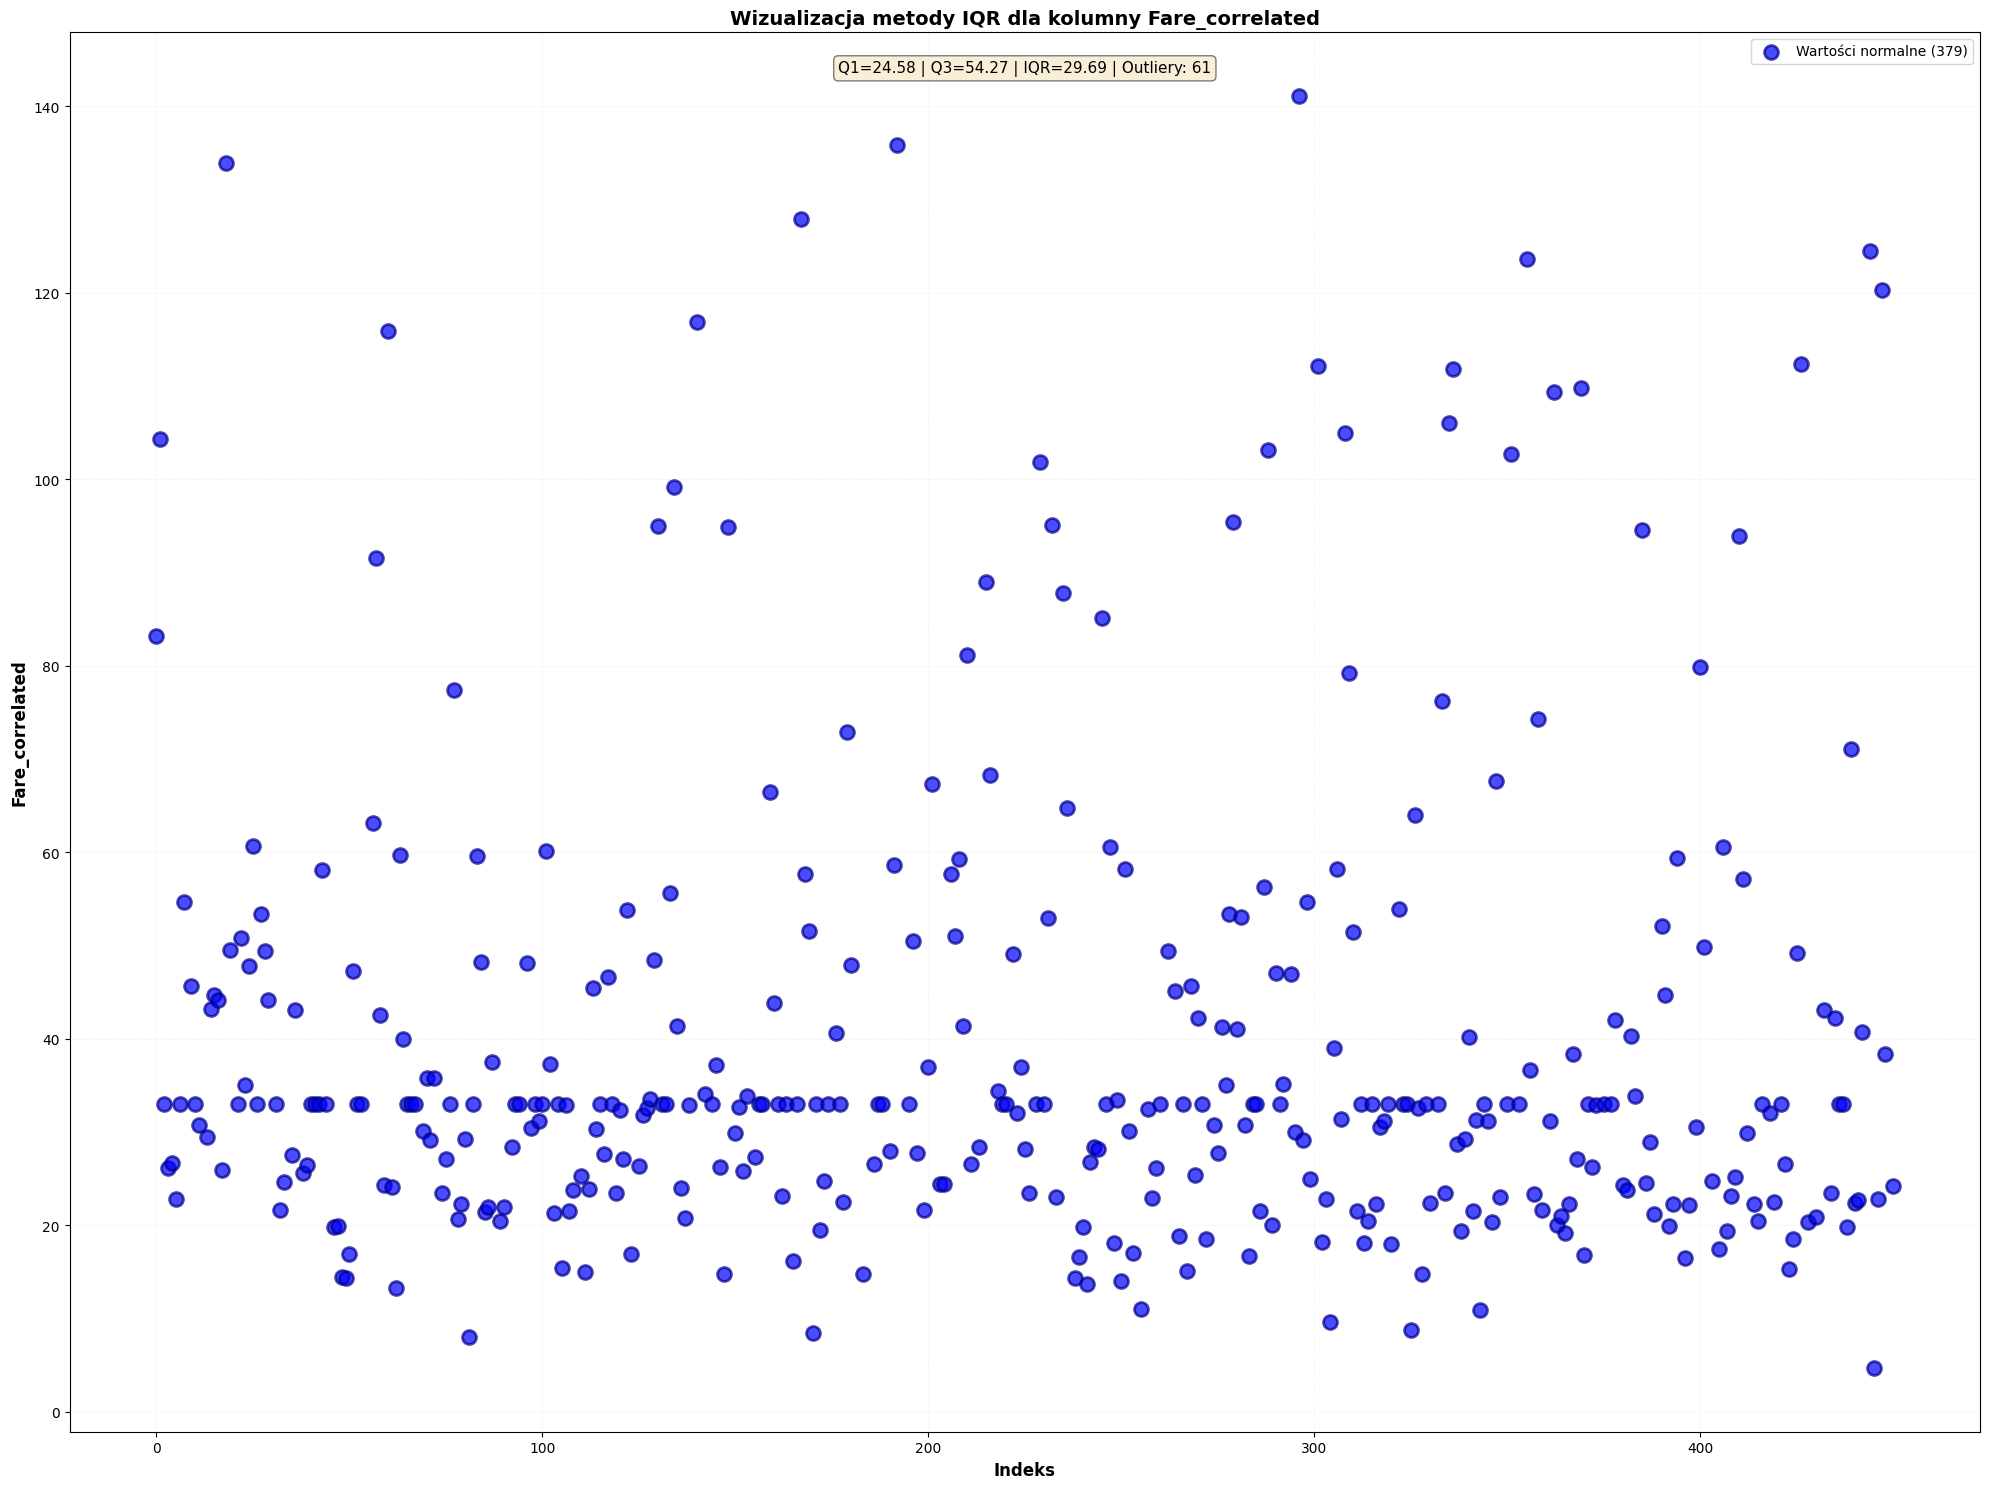

In [110]:
  plt.figure(figsize=(20, 15))

  plt.scatter(czysty_df.index, czysty_df[col], c='blue', s=100,
            alpha=0.7, edgecolors='darkblue', linewidth=2,
            label=f'Wartości normalne ({len(czysty_df)})', zorder=5)

  plt.xlabel('Indeks', fontsize=12, fontweight='bold')
  plt.ylabel(col, fontsize=12, fontweight='bold')
  plt.title('Wizualizacja metody IQR dla kolumny ' + col, fontsize=14, fontweight='bold')
  plt.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
  plt.legend(loc='best', fontsize=10)

  plt.text(0.5, 0.98, info, transform=plt.gca().transAxes,
          fontsize=11, va='top', ha='center',
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

  plt.tight_layout()
  plt.show()

# 2.3 Feature Engineering 


In [134]:
#Ratio (stosunek dwóch kolumn)
czysty_df['FamilySize'] = czysty_df['SibSp'] + czysty_df['Parch']
czysty_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Fare_correlated,FamilySize
0,1190.0,0.0,1.0,"Loring, Mr. Joseph Holland",male,30.0,0.0,0.0,113801,45.5000,S,83.228010,0.0
1,931.0,0.0,2.0,"Hee, Mr. Ling",male,27.0,0.0,0.0,1601,56.4958,S,104.304171,0.0
2,1227.0,0.0,1.0,"Maguire, Mr. John Edward",male,30.0,0.0,0.0,110469,14.5000,S,33.070958,0.0
3,1290.0,0.0,3.0,"Larsson-Rondberg, Mr. Edvard A",male,22.0,0.0,0.0,347065,7.7750,S,26.139860,0.0
4,1045.0,1.0,3.0,"Klasen, Mrs. (Hulda Kristina Eugenia Lofqvist)",female,36.0,0.0,2.0,350405,12.1833,S,26.644707,2.0


In [135]:
# Binning (przedziały) wiek → grupy
czysty_df['AgeGroup'] = pd.cut(czysty_df['Age'],
                         bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child','Teen','Young','Adult','Senior'])

czysty_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Fare_correlated,FamilySize,AgeGroup
0,1190.0,0.0,1.0,"Loring, Mr. Joseph Holland",male,30.0,0.0,0.0,113801,45.5000,S,83.228010,0.0,Young
1,931.0,0.0,2.0,"Hee, Mr. Ling",male,27.0,0.0,0.0,1601,56.4958,S,104.304171,0.0,Young
2,1227.0,0.0,1.0,"Maguire, Mr. John Edward",male,30.0,0.0,0.0,110469,14.5000,S,33.070958,0.0,Young
3,1290.0,0.0,3.0,"Larsson-Rondberg, Mr. Edvard A",male,22.0,0.0,0.0,347065,7.7750,S,26.139860,0.0,Young
4,1045.0,1.0,3.0,"Klasen, Mrs. (Hulda Kristina Eugenia Lofqvist)",female,36.0,0.0,2.0,350405,12.1833,S,26.644707,2.0,Adult


In [136]:
#np agregacje średnia wieku w klasie średnia cena biletu dla klasy  liczba osób z tym samym biletem średnia przeżywalność grupy
# agregacje
czysty_df['AvgFareByClass'] = czysty_df.groupby('Pclass')['Fare'].transform('mean')
czysty_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Fare_correlated,FamilySize,AgeGroup,AvgFareByClass
0,1190.0,0.0,1.0,"Loring, Mr. Joseph Holland",male,30.0,0.0,0.0,113801,45.5000,S,83.228010,0.0,Young,88.219444
1,931.0,0.0,2.0,"Hee, Mr. Ling",male,27.0,0.0,0.0,1601,56.4958,S,104.304171,0.0,Young,31.179072
2,1227.0,0.0,1.0,"Maguire, Mr. John Edward",male,30.0,0.0,0.0,110469,14.5000,S,33.070958,0.0,Young,88.219444
3,1290.0,0.0,3.0,"Larsson-Rondberg, Mr. Edvard A",male,22.0,0.0,0.0,347065,7.7750,S,26.139860,0.0,Young,13.962979
4,1045.0,1.0,3.0,"Klasen, Mrs. (Hulda Kristina Eugenia Lofqvist)",female,36.0,0.0,2.0,350405,12.1833,S,26.644707,2.0,Adult,13.962979


In [137]:
#Interakcje luksus / status
czysty_df['Fare_per_person'] = czysty_df['Fare'] / (czysty_df['FamilySize'] + 1)
czysty_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Fare_correlated,FamilySize,AgeGroup,AvgFareByClass,Fare_per_person
0,1190.0,0.0,1.0,"Loring, Mr. Joseph Holland",male,30.0,0.0,0.0,113801,45.5000,S,83.228010,0.0,Young,88.219444,45.5000
1,931.0,0.0,2.0,"Hee, Mr. Ling",male,27.0,0.0,0.0,1601,56.4958,S,104.304171,0.0,Young,31.179072,56.4958
2,1227.0,0.0,1.0,"Maguire, Mr. John Edward",male,30.0,0.0,0.0,110469,14.5000,S,33.070958,0.0,Young,88.219444,14.5000
3,1290.0,0.0,3.0,"Larsson-Rondberg, Mr. Edvard A",male,22.0,0.0,0.0,347065,7.7750,S,26.139860,0.0,Young,13.962979,7.7750
4,1045.0,1.0,3.0,"Klasen, Mrs. (Hulda Kristina Eugenia Lofqvist)",female,36.0,0.0,2.0,350405,12.1833,S,26.644707,2.0,Adult,13.962979,4.0611


In [139]:
czysty_df[['Survived','Pclass','Age','SibSp','Parch','Fare','Fare_correlated','FamilySize','AvgFareByClass','Fare_per_person']].corr()

,Survived,Pclass,Age,SibSp,Parch,Fare,Fare_correlated,FamilySize,AvgFareByClass,Fare_per_person
Survived,1.000000,0.000517,-0.007455,0.095595,0.160263,0.176747,0.177280,0.159768,0.080442,0.139848
Pclass,0.000517,1.000000,-0.174066,0.037519,0.054671,-0.141425,-0.144781,0.057405,-0.390011,-0.131947
Age,-0.007455,-0.174066,1.000000,-0.078937,-0.043305,0.236803,0.239925,-0.074577,0.200615,0.217312
SibSp,0.095595,0.037519,-0.078937,1.000000,0.308872,0.170880,0.173527,0.790347,-0.039946,-0.075933
Parch,0.160263,0.054671,-0.043305,0.308872,1.000000,0.245685,0.246133,0.826819,0.012464,-0.054784
Fare,0.176747,-0.141425,0.236803,0.170880,0.245685,1.000000,0.998013,0.259315,0.362618,0.812311
Fare_correlated,0.177280,-0.144781,0.239925,0.173527,0.246133,0.998013,1.000000,0.261170,0.366750,0.808732
FamilySize,0.159768,0.057405,-0.074577,0.790347,0.826819,0.259315,0.261170,1.000000,-0.015595,-0.080195
AvgFareByClass,0.080442,-0.390011,0.200615,-0.039946,0.012464,0.362618,0.366750,-0.015595,1.000000,0.299853
Fare_per_person,0.139848,-0.131947,0.217312,-0.075933,-0.054784,0.812311,0.808732,-0.080195,0.299853,1.000000


# 3.1 Quality Control

In [140]:
duplicate_count = czysty_df.duplicated().sum()
print("Liczba duplikatów:", duplicate_count)

# usunięcie
czysty_df = czysty_df.drop_duplicates()

Liczba duplikatów: 0


In [143]:
print("Niepoprawny wiek:", (czysty_df['Age'] < 0).sum())
print("Za duży wiek:", (czysty_df['Age'] > 100).sum())

print("Ujemne Fare:", (czysty_df['Fare'] < 0).sum())

print("Niepoprawne klasy:", (~czysty_df['Pclass'].isin([1,2,3])).sum())

Niepoprawny wiek: 7
Za duży wiek: 4
Ujemne Fare: 0
Niepoprawne klasy: 13


In [144]:
from scipy.stats import shapiro

stat, p = shapiro(czysty_df['Age'].dropna())
print("Age p-value:", p)

stat, p = shapiro(czysty_df['Fare'].dropna())
print("Fare p-value:", p)

Age p-value: 8.28028229198015e-21
Fare p-value: 2.0508901435432744e-33


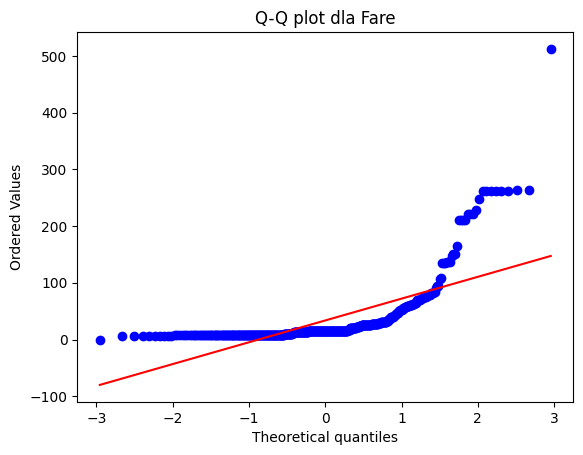

In [145]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(czysty_df['Fare'].dropna(), dist="norm", plot=plt)
plt.title("Q-Q plot dla Fare")
plt.show()

In [146]:
wrong_family = (
    czysty_df['FamilySize'] != czysty_df['SibSp'] + czysty_df['Parch']
).sum()

print("Niespójne FamilySize:", wrong_family)

Niespójne FamilySize: 0


# 3.2 Visualization

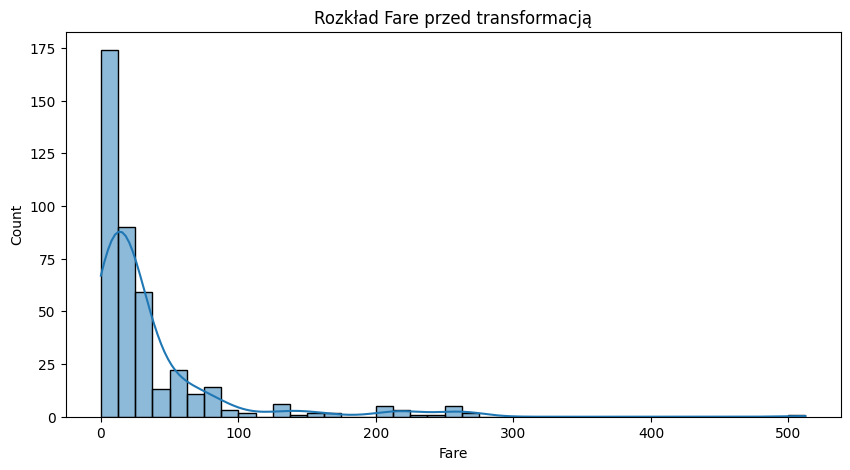

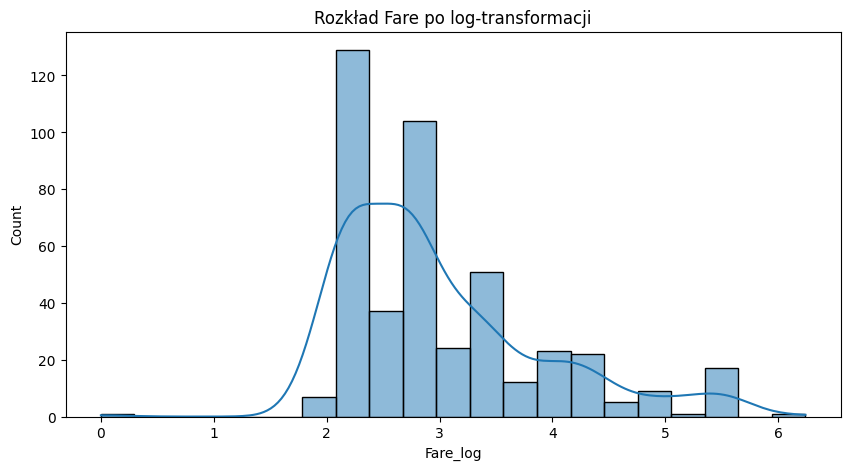

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))
sns.histplot(df['Fare'].dropna(), kde=True)
plt.title("Rozkład Fare przed transformacją")
plt.show()

# po transformacji log
czysty_df['Fare_log'] = np.log1p(czysty_df['Fare'])

plt.figure(figsize=(10,5))
sns.histplot(czysty_df['Fare_log'], kde=True)
plt.title("Rozkład Fare po log-transformacji")
plt.show()

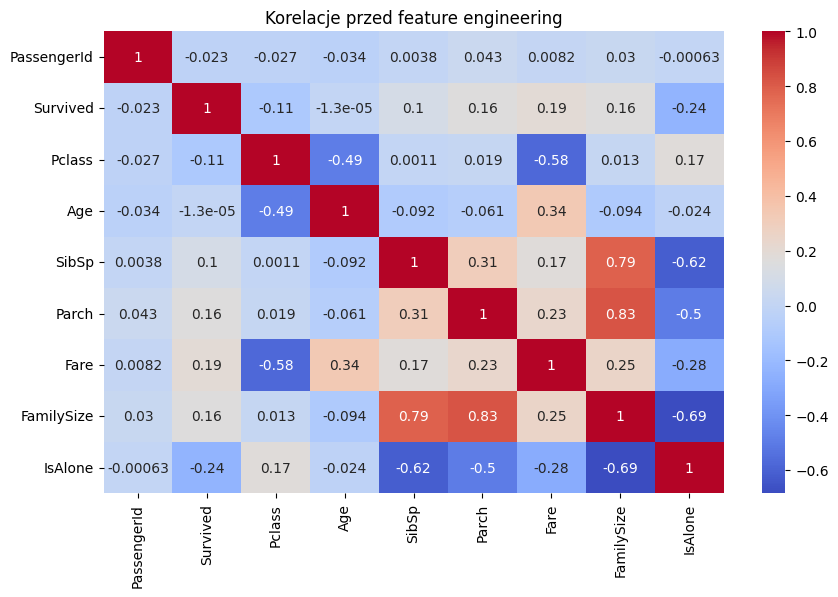

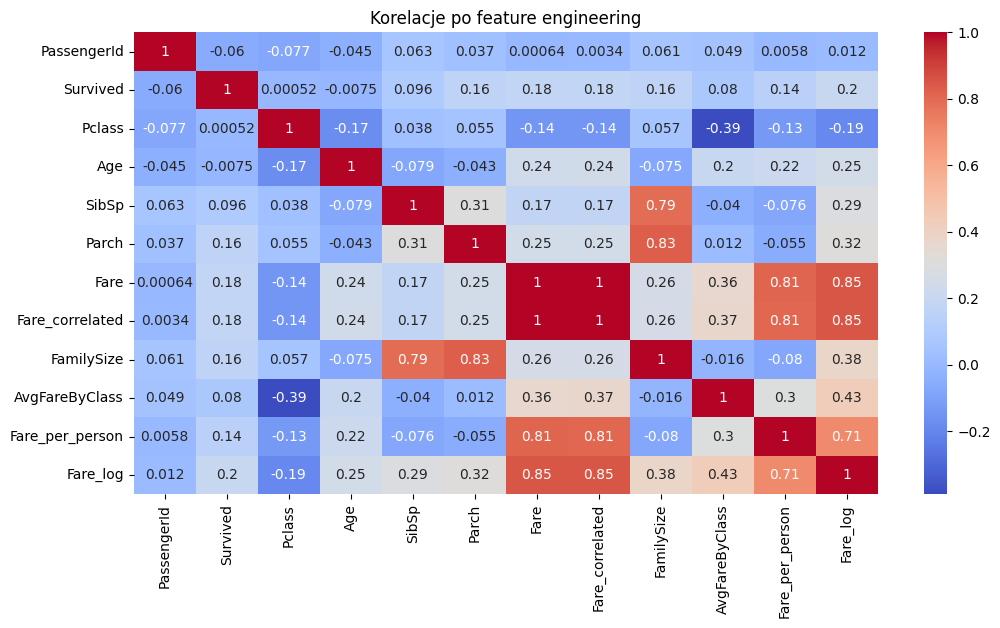

In [148]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Korelacje przed feature engineering")
plt.show()

plt.figure(figsize=(12,6))
sns.heatmap(czysty_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Korelacje po feature engineering")
plt.show()

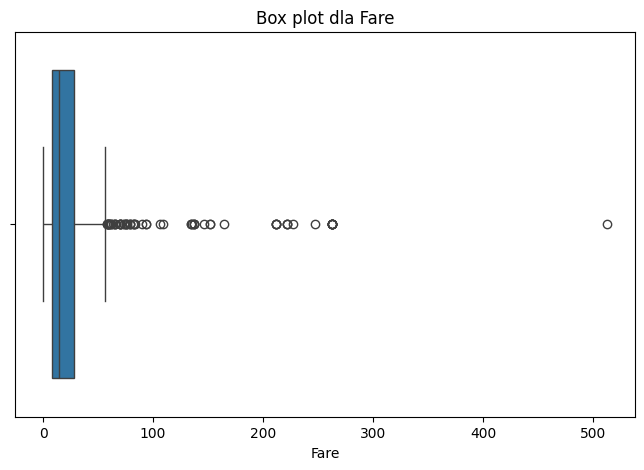

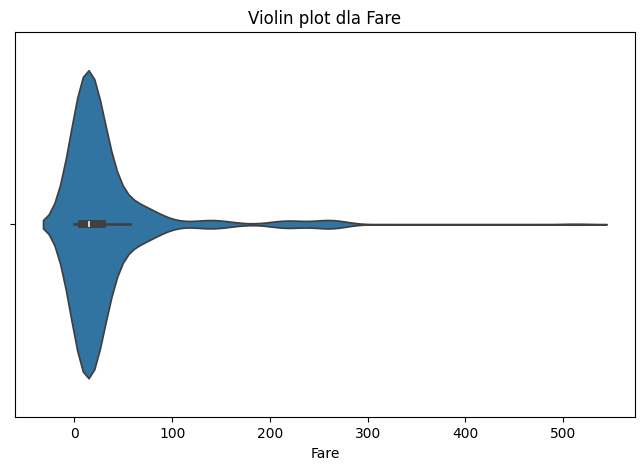

In [149]:
plt.figure(figsize=(8,5))
sns.boxplot(x=czysty_df['Fare'])
plt.title("Box plot dla Fare")
plt.show()

plt.figure(figsize=(8,5))
sns.violinplot(x=czysty_df['Fare'])
plt.title("Violin plot dla Fare")
plt.show()

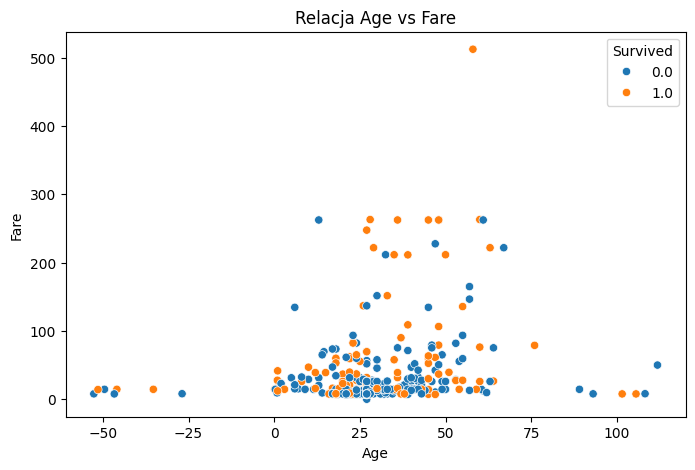

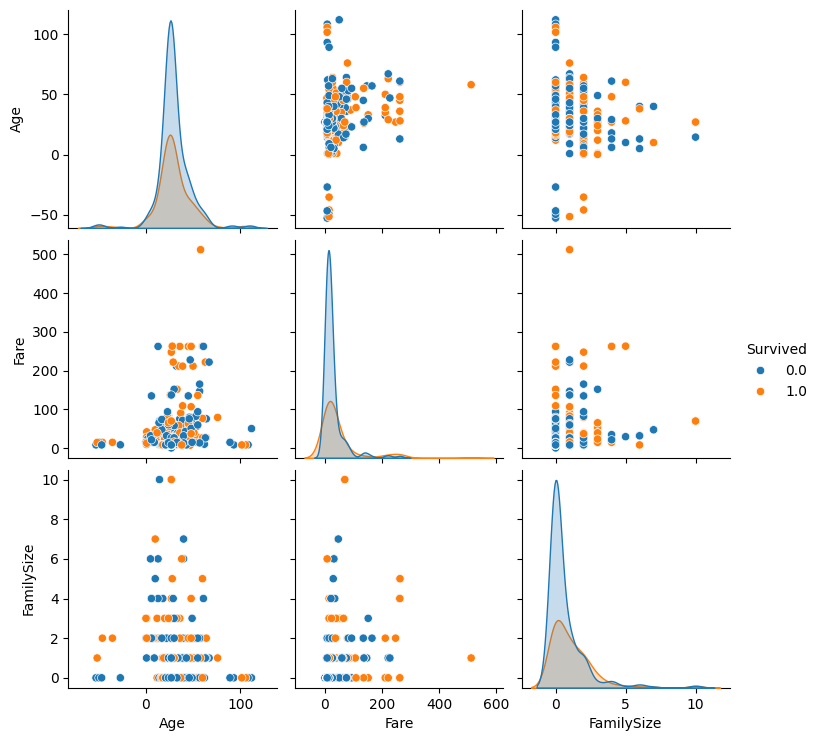

In [150]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=czysty_df, x='Age', y='Fare', hue='Survived')
plt.title("Relacja Age vs Fare")
plt.show()

sns.pairplot(
    czysty_df[['Age','Fare','FamilySize','Survived']],
    hue='Survived'
)
plt.show()